In [ ]:
!pip install torch
!pip install lion-pytorch
!pip install torchvision
!pip install torch_optimizer
!pip install --upgrade ucimlrepo
!pip install optuna
!pip install optunahub
!pip install xgboost
!pip install -U scikit-fuzzy

In [ ]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch_optimizer as toptim

In [ ]:
# SciKit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

# Dimension reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
import itertools
import random
import optuna
import time

from lion_pytorch import Lion
from torch.utils.data import DataLoader, TensorDataset
from optuna.samplers import TPESampler, NSGAIISampler, GridSampler, RandomSampler
from optuna.pruners import HyperbandPruner

In [ ]:
# Ploting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

---

## To access the datasets and load them from Google Drive go back to the Main Folder and look for **GoogleDrive.jpg**

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load data from file
root_dir = '/content/drive/MyDrive/Colab Notebooks/IntroAI/StreetLight/'

In [ ]:
df = pd.read_csv(root_dir + "smart_lighting_dataset_2024.csv")

In [ ]:
df.head()

,timestamp,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,weather_condition,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity,energy_consumption_kwh,lighting_action_class
0,2024-01-01 00:00:00,3,0.00,0,22.08,7,Monday,Night,Cloudy,0,3.83,3.27,26.0,4.54,54.40,1.144,0
1,2024-01-01 00:43:00,3,35.78,0,19.19,6,Monday,Night,Cloudy,0,4.61,1.50,18.9,2.42,89.75,2.069,1
2,2024-01-01 01:27:00,7,0.00,0,27.78,9,Monday,Night,Clear,0,4.21,2.51,27.6,2.85,82.25,1.687,1
3,2024-01-01 02:11:00,2,0.00,1,33.11,16,Monday,Night,Foggy,0,6.16,0.34,23.1,2.45,72.57,1.631,1
4,2024-01-01 02:55:00,4,0.00,1,27.07,11,Monday,Night,Clear,0,5.72,1.52,26.4,3.49,78.79,1.737,1


In [ ]:
df_train = df.copy()

In [ ]:
# changing the 'timestamp' column to an datetime object
df_train['timestamp'] = pd.to_datetime(df_train['timestamp'])

In [ ]:
# Splitting the datetime object
df_train['hour']    = df_train['timestamp'].dt.hour
df_train['weekday'] = df_train['timestamp'].dt.weekday   # 0 = Monday
df_train['month']   = df_train['timestamp'].dt.month
df_train['is_weekend'] = df_train['weekday'].isin([5, 6]).astype(int)

In [ ]:
# Droping the timestap column after splitting it
df_train = df_train.drop(columns=['timestamp'])

# We won't use the binary classification here. We want to predict a regression quantity
df_train = df_train.drop(columns=['lighting_action_class'])

# Droping redundat columns
df_train = df_train.drop(columns=['day_of_week'])

In [ ]:
# One-hot encoding which changes a category into a set of independent binary signals.
df_train = pd.get_dummies(df_train, columns=['zone_id', 'weather_condition', 'time_of_day'], drop_first=False)

In [ ]:
display(df_train)

,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity,...,zone_id_11,zone_id_12,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Foggy,weather_condition_Rainy,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,0.00,0,22.08,7,0,3.83,3.27,26.0,4.54,54.40,...,False,False,False,True,False,False,False,False,False,True
1,35.78,0,19.19,6,0,4.61,1.50,18.9,2.42,89.75,...,False,False,False,True,False,False,False,False,False,True
2,0.00,0,27.78,9,0,4.21,2.51,27.6,2.85,82.25,...,False,False,True,False,False,False,False,False,False,True
3,0.00,1,33.11,16,0,6.16,0.34,23.1,2.45,72.57,...,False,False,False,False,True,False,False,False,False,True
4,0.00,1,27.07,11,0,5.72,1.52,26.4,3.49,78.79,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.00,0,24.84,13,0,4.19,3.96,15.6,4.49,88.85,...,False,False,True,False,False,False,False,False,False,True
11996,170.09,0,20.16,5,0,3.95,2.24,20.5,1.76,89.41,...,False,False,True,False,False,False,False,False,False,True
11997,176.03,0,28.53,8,0,3.02,4.14,35.3,3.53,93.44,...,False,False,False,False,False,True,False,False,False,True
11998,375.50,1,34.16,11,0,3.94,3.82,30.0,2.52,69.08,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
df_train.columns.values

array(['ambient_light_lux', 'motion_detected', 'temperature_celsius',
       'occupancy_count', 'special_event_flag', 'energy_price_per_kwh',
       'prev_hour_energy_usage_kwh', 'traffic_density',
       'avg_pedestrian_speed', 'adjusted_light_intensity',
       'energy_consumption_kwh', 'hour', 'weekday', 'month', 'is_weekend',
       'zone_id_1', 'zone_id_2', 'zone_id_3', 'zone_id_4', 'zone_id_5',
       'zone_id_6', 'zone_id_7', 'zone_id_8', 'zone_id_9', 'zone_id_10',
       'zone_id_11', 'zone_id_12', 'weather_condition_Clear',
       'weather_condition_Cloudy', 'weather_condition_Foggy',
       'weather_condition_Rainy', 'time_of_day_Afternoon',
       'time_of_day_Evening', 'time_of_day_Morning', 'time_of_day_Night'],
      dtype=object)

In [ ]:
df_fuzzy = df_train.copy()

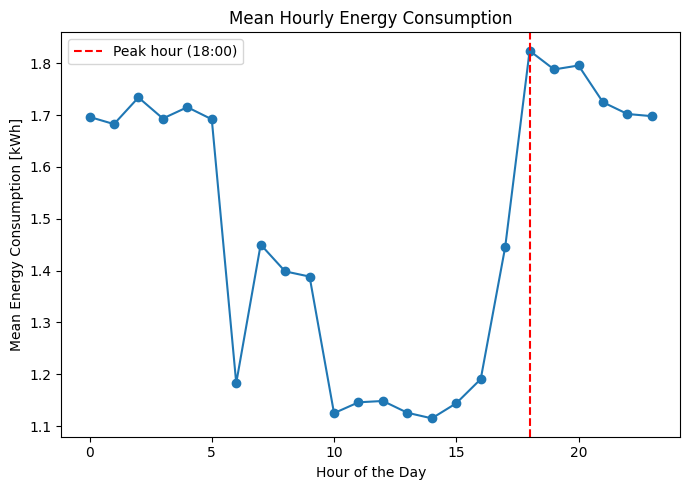

In [ ]:
plt.figure(figsize=(7, 5))
hourly_mean = (df_train.groupby('hour', as_index=False)['energy_consumption_kwh'].mean())

plt.plot(hourly_mean["hour"], hourly_mean["energy_consumption_kwh"], marker="o")
peak_hour = hourly_mean.loc[hourly_mean["energy_consumption_kwh"].idxmax(), "hour"]
plt.axvline(peak_hour, linestyle="--", color="red", label=f"Peak hour ({peak_hour}:00)")
plt.xlabel('Hour of the Day')
plt.ylabel('Mean Energy Consumption [kWh]')
plt.title('Mean Hourly Energy Consumption')
plt.tight_layout()
plt.legend()
plt.show()

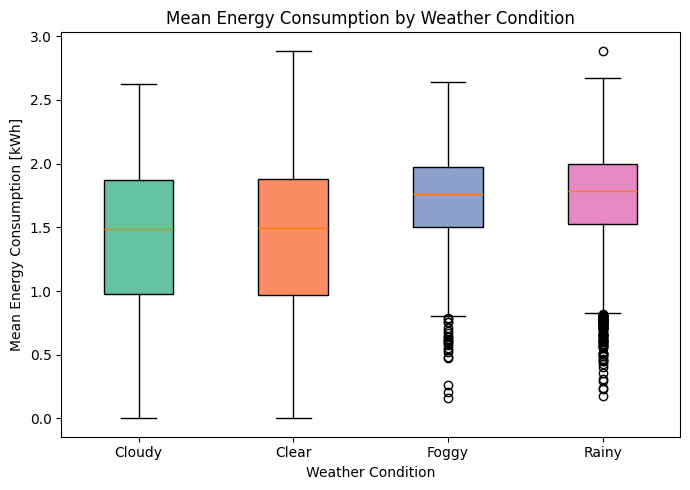

In [ ]:
weather_cols = [c for c in df_train.columns if c.startswith("weather_condition_")]
df_weather = df_train.copy()

df_weather["Weather"] = (
    df_weather[weather_cols]
    .idxmax(axis=1)
    .str.replace("weather_condition_", "")
)

weather_order = df_weather["Weather"].unique()
data = [
    df_weather.loc[df_weather["Weather"] == w, "energy_consumption_kwh"]
    for w in weather_order
]

plt.figure(figsize=(7, 5))

bp = plt.boxplot(
    data,
    patch_artist=True,
    tick_labels=weather_order,
    showfliers=True
)

colors = plt.cm.Set2.colors  # professional, colorblind-safe
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

plt.xlabel("Weather Condition")
plt.ylabel("Mean Energy Consumption [kWh]")
plt.title("Mean Energy Consumption by Weather Condition")
plt.tight_layout()
plt.show()

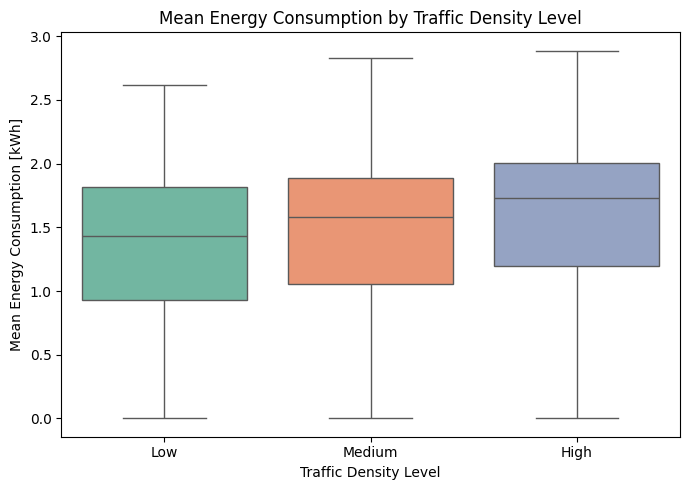

In [ ]:
df_box = df_train.copy()
df_box["traffic_density_bin"] = pd.qcut(
    df_box["traffic_density"],
    q=3,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_box,
    x="traffic_density_bin",
    y="energy_consumption_kwh",
    palette="Set2",
    hue="traffic_density_bin"
)

plt.xlabel("Traffic Density Level")
plt.ylabel("Mean Energy Consumption [kWh]")
plt.title("Mean Energy Consumption by Traffic Density Level")
plt.tight_layout()
plt.show()

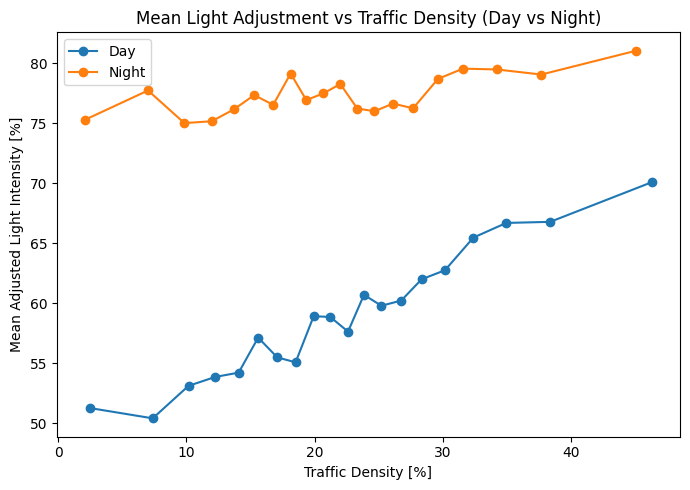

In [ ]:
df_night = df_train.copy()
df_night["day_period"] = np.where(
    (df_night["hour"] >= 7) & (df_night["hour"] < 19),
    "Day",
    "Night"
)

plt.figure(figsize=(7, 5))

for period in ["Day", "Night"]:
    subset = df_night[df_night["day_period"] == period]
    bins = pd.qcut(subset["traffic_density"], q=20, duplicates="drop")
    mean_light = subset.groupby(bins, observed=False)["adjusted_light_intensity"].mean()
    mean_density = subset.groupby(bins, observed=False)["traffic_density"].mean()

    plt.plot(
        mean_density,
        mean_light,
        marker="o",
        label=period
    )

plt.xlabel("Traffic Density [%]")
plt.ylabel("Mean Adjusted Light Intensity [%]")
plt.title("Mean Light Adjustment vs Traffic Density (Day vs Night)")
plt.legend()
plt.tight_layout()
plt.show()

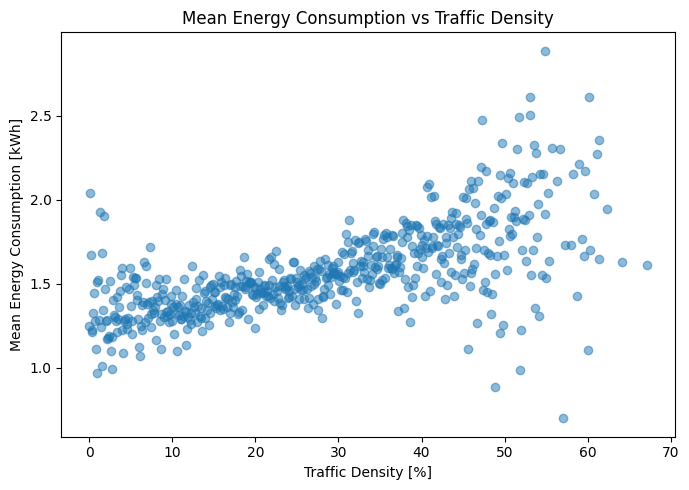

In [ ]:
traffic_energy_mean = (df_train.groupby("traffic_density", as_index=False)['energy_consumption_kwh'].mean())

plt.figure(figsize=(7, 5))
plt.scatter(traffic_energy_mean["traffic_density"], traffic_energy_mean["energy_consumption_kwh"], alpha=0.5)

plt.xlabel("Traffic Density [%]")
plt.ylabel("Mean Energy Consumption [kWh]")
plt.title("Mean Energy Consumption vs Traffic Density")
plt.tight_layout()
plt.show()

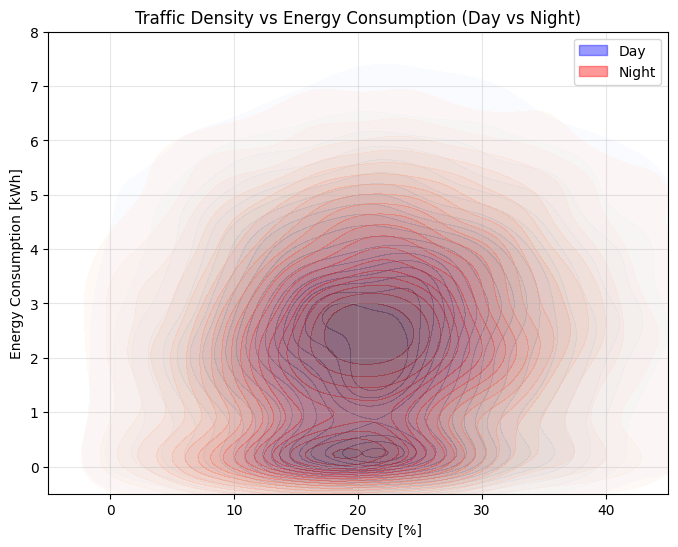

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8,6))

# Day
subset_day = df_night[df_night["day_period"] == "Day"]
sns.kdeplot(
    x=subset_day["traffic_density"],
    y=subset_day["prev_hour_energy_usage_kwh"],
    fill=True,
    cmap="Blues",
    alpha=0.4,
    thresh=0.05,
    levels=20,
    ax=ax
)

# Night
subset_night = df_night[df_night["day_period"] == "Night"]
sns.kdeplot(
    x=subset_night["traffic_density"],
    y=subset_night["prev_hour_energy_usage_kwh"],
    fill=True,
    cmap="Reds",
    alpha=0.4,
    thresh=0.05,
    levels=20,
    ax=ax
)

ax.set_xlim(-5, 45)
ax.set_ylim(-0.5, 8)
ax.set_xlabel("Traffic Density [%]")
ax.set_ylabel("Energy Consumption [kWh]")
ax.set_title("Traffic Density vs Energy Consumption (Day vs Night)")

# Create proxy artists for the legend
blue_patch = mpatches.Patch(color='blue', label='Day', alpha=0.4)
red_patch = mpatches.Patch(color='red', label='Night', alpha=0.4)
ax.legend(handles=[blue_patch, red_patch])

ax.grid(alpha=0.3)
plt.show()

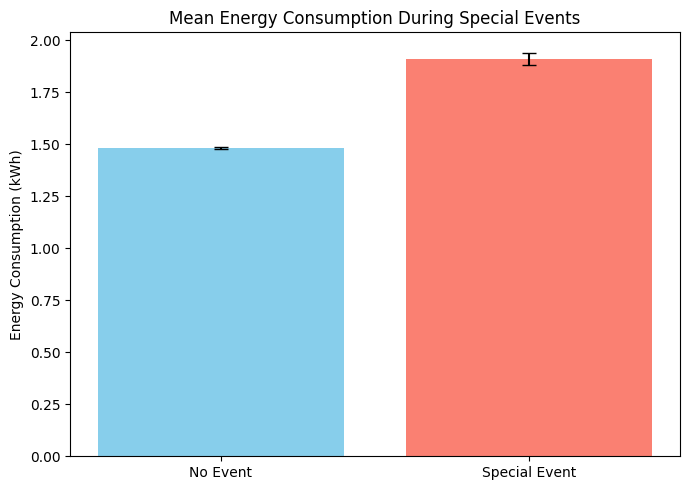

In [ ]:
event_0 = df_train[df_train["special_event_flag"] == 0]["energy_consumption_kwh"]
event_1 = df_train[df_train["special_event_flag"] == 1]["energy_consumption_kwh"]

means = [event_0.mean(), event_1.mean()]
sems = [event_0.sem(), event_1.sem()]

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Event", "Special Event"],
    means,
    yerr=sems,
    capsize=5,
    color=["skyblue", "salmon"]
)

plt.ylabel("Energy Consumption (kWh)")
plt.title("Mean Energy Consumption During Special Events")
plt.tight_layout()
plt.show()

---

### Checking the skewness of some of the features. Skewness matters  because many algorithms assume normal (symmetric) distribution, causing skewed data to bias models, distort relationships, increase training time, and make feature importance misleading, requiring transformations (like log transform) to improve performance.

---

In [ ]:
# List of skewed features to plot
features = ['ambient_light_lux', 'occupancy_count', 'prev_hour_energy_usage_kwh', 'energy_consumption_kwh', 'adjusted_light_intensity']

# Compute skewness
print("Skewness:")
for f in features:
    skew_val = df_train[f].skew()
    print(f"{f}: {skew_val:.2f}")

Skewness:
ambient_light_lux: 5.72
occupancy_count: 11.76
prev_hour_energy_usage_kwh: 0.43
energy_consumption_kwh: -0.35
adjusted_light_intensity: -0.50


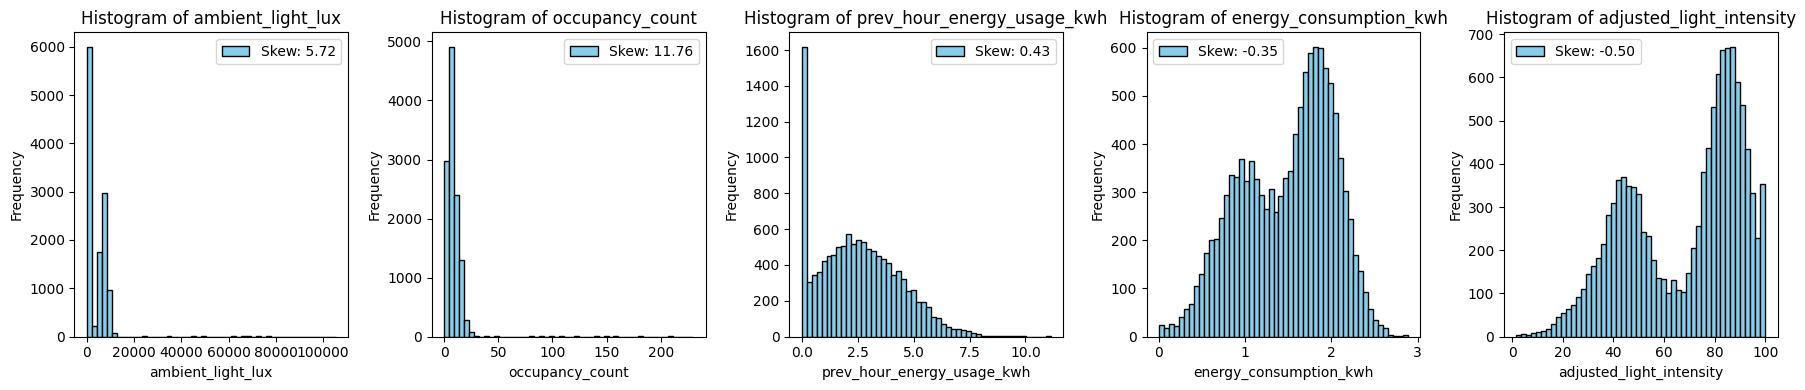

In [ ]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(features), figsize=(18, 4))

for i, f in enumerate(features):
    skew_val = df_train[f].skew()
    axes[i].hist(df_train[f], bins=50, color='skyblue', edgecolor='k', label=f"Skew: {skew_val:.2f}")
    axes[i].set_title(f"Histogram of {f}")
    axes[i].set_xlabel(f)
    axes[i].legend()
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Apply log1p to highly skewed numeric features
df_train['ambient_light_lux'] = np.log1p(df_train['ambient_light_lux'])
df_train['occupancy_count'] = np.log1p(df_train['occupancy_count'])

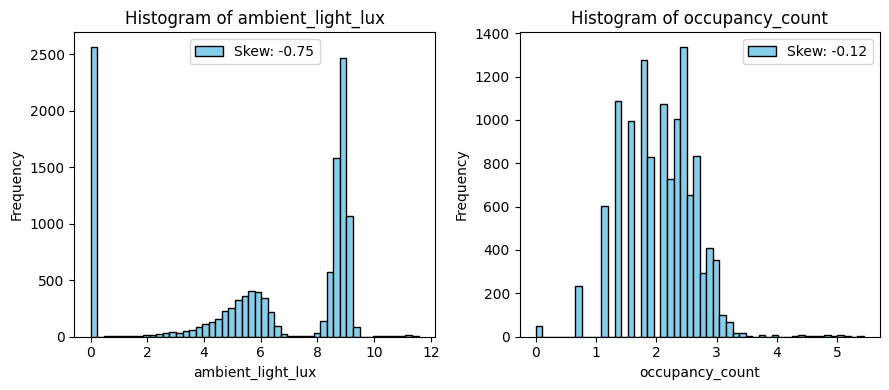

In [ ]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(features)-3, figsize=(9, 4))

for i, f in enumerate(features[:2]):
    skew_val = df_train[f].skew()
    axes[i].hist(df_train[f], bins=50, color='skyblue', edgecolor='k', label=f"Skew: {skew_val:.2f}")
    axes[i].set_title(f"Histogram of {f}")
    axes[i].set_xlabel(f)
    axes[i].legend()
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

---

### Choosing the **target_value** and prepering the X, y input DataFrames

---

In [ ]:
target_feature = 'adjusted_light_intensity'
# X as a DataFrame to retain column names for fuzzy rules later
X = df_train.drop(columns=[target_feature])

# Target
y = df_train[target_feature]

display(X)

,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,energy_consumption_kwh,...,zone_id_11,zone_id_12,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Foggy,weather_condition_Rainy,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,0.000000,0,22.08,2.079442,0,3.83,3.27,26.0,4.54,1.144,...,False,False,False,True,False,False,False,False,False,True
1,3.604954,0,19.19,1.945910,0,4.61,1.50,18.9,2.42,2.069,...,False,False,False,True,False,False,False,False,False,True
2,0.000000,0,27.78,2.302585,0,4.21,2.51,27.6,2.85,1.687,...,False,False,True,False,False,False,False,False,False,True
3,0.000000,1,33.11,2.833213,0,6.16,0.34,23.1,2.45,1.631,...,False,False,False,False,True,False,False,False,False,True
4,0.000000,1,27.07,2.484907,0,5.72,1.52,26.4,3.49,1.737,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.000000,0,24.84,2.639057,0,4.19,3.96,15.6,4.49,1.872,...,False,False,True,False,False,False,False,False,False,True
11996,5.142190,0,20.16,1.791759,0,3.95,2.24,20.5,1.76,1.815,...,False,False,True,False,False,False,False,False,False,True
11997,5.176319,0,28.53,2.197225,0,3.02,4.14,35.3,3.53,2.206,...,False,False,False,False,False,True,False,False,False,True
11998,5.930918,1,34.16,2.484907,0,3.94,3.82,30.0,2.52,1.717,...,False,False,True,False,False,False,False,False,False,True


--------------------------------------------------------------------------------
##Creating a **Pairplot** of the dataset.
--------------------------------------------------------------------------------

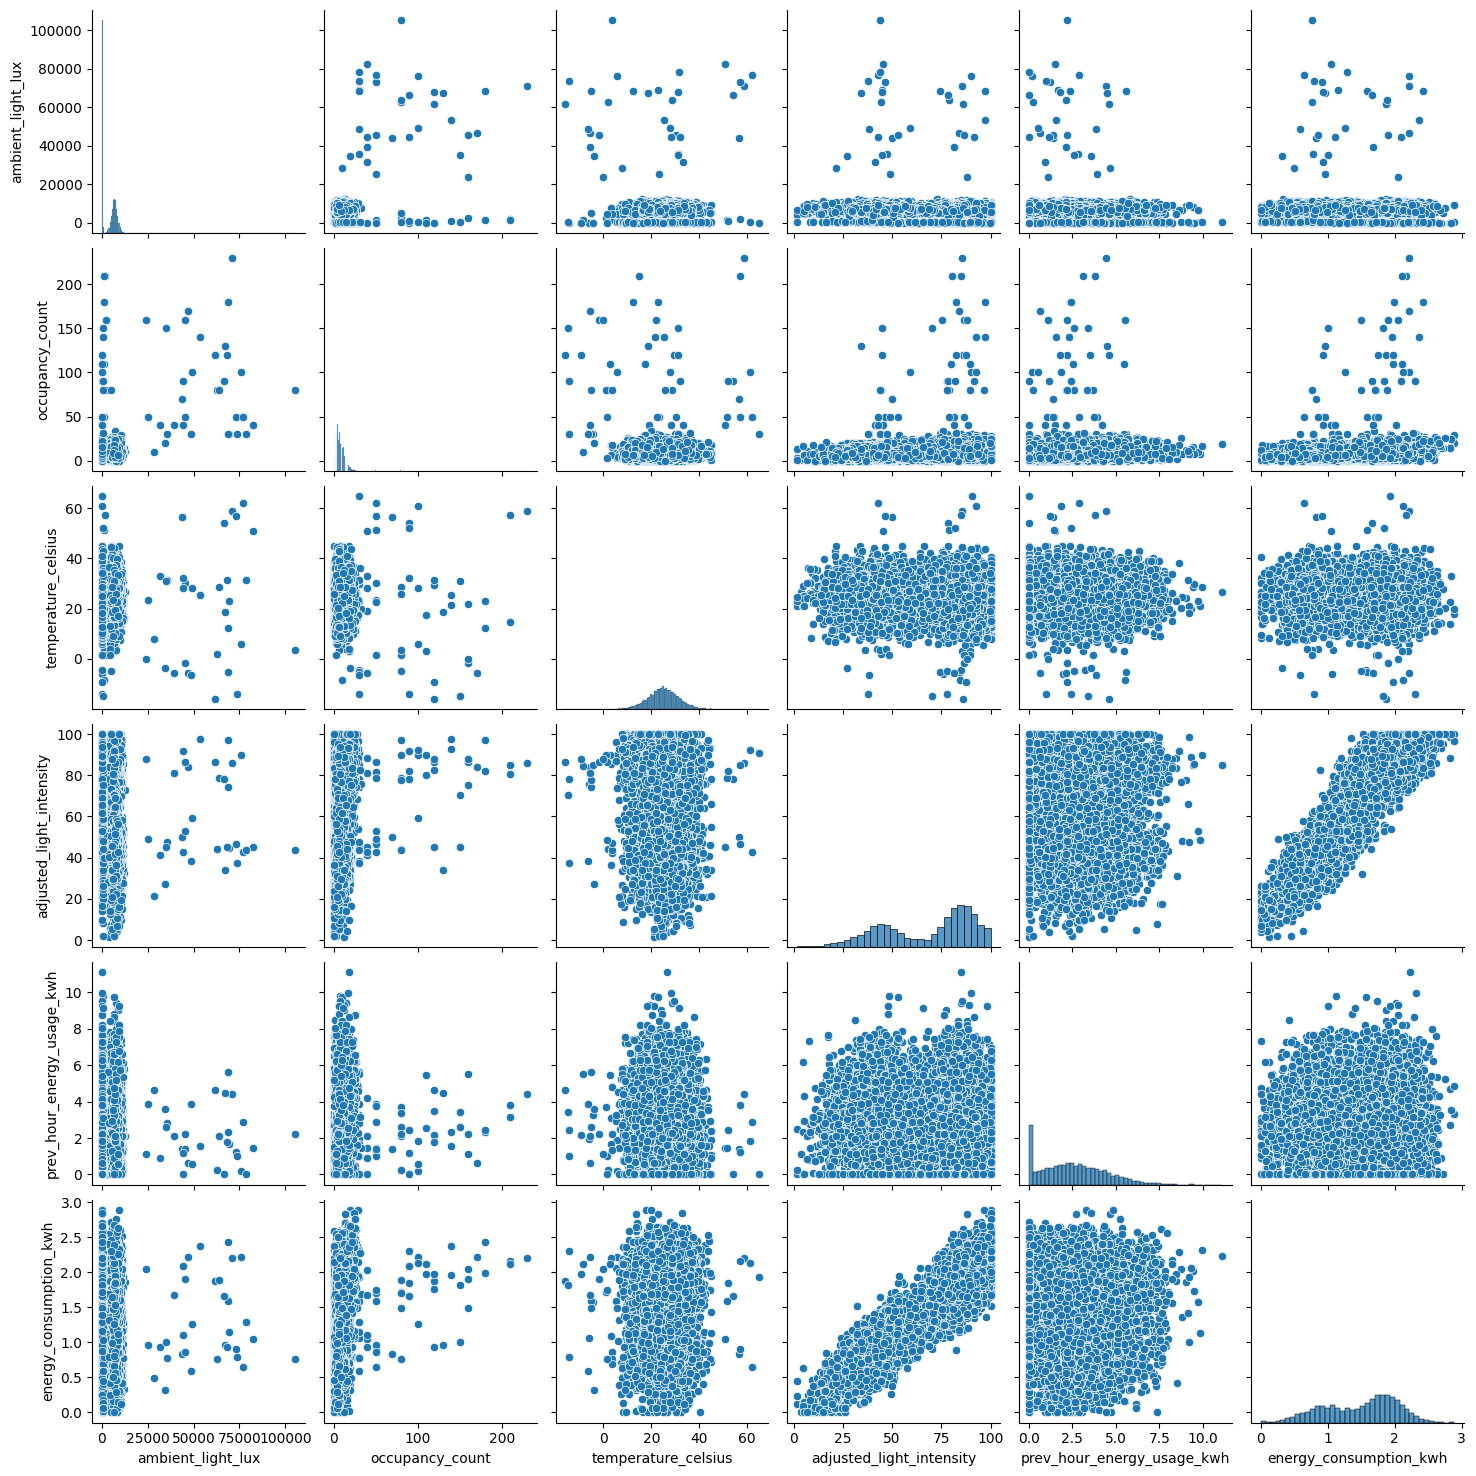

In [ ]:
plot_features = [
    'ambient_light_lux',
    'occupancy_count',
    'temperature_celsius',
    'adjusted_light_intensity',
    'prev_hour_energy_usage_kwh',
    'energy_consumption_kwh'
]

sns.pairplot(df[plot_features])
plt.show()

---

## Train, split, test, and normalization of the dataset + Adding Safety Feature

---

In [ ]:
# Split the unscaled DataFrame features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

safety_cols = [
    "occupancy_count",
    "traffic_density",
    "avg_pedestrian_speed"
]

mm_scaler = MinMaxScaler()

X_train_safety_norm = mm_scaler.fit_transform(X_train[safety_cols])
X_test_safety_norm  = mm_scaler.transform(X_test[safety_cols])

motion_train = X_train["motion_detected"].values
motion_test  = X_test["motion_detected"].values

special_ev_train = X_train["special_event_flag"].values
special_ev_test  = X_test["special_event_flag"].values

occ_tr, traffic_tr, speed_tr = X_train_safety_norm.T
occ_te, traffic_te, speed_te = X_test_safety_norm.T

base_risk_train = (
    0.15 * motion_train +
    0.35 * occ_tr +
    0.35 * traffic_tr +
    0.15 * speed_tr
)

base_risk_test = (
    0.15 * motion_test +
    0.35 * occ_te +
    0.35 * traffic_te +
    0.15 * speed_te
)

# Adding the special_event_flag feature which also increases the risk
EVENT_AMPLIFICATION = 0.30

safety_risk_train = base_risk_train * (
    1.0 + EVENT_AMPLIFICATION * special_ev_train
)

safety_risk_test = base_risk_test * (
    1.0 + EVENT_AMPLIFICATION * special_ev_test
)

safety_risk_train = np.clip(safety_risk_train, 0.0, 1.0)
safety_risk_test  = np.clip(safety_risk_test, 0.0, 1.0)


X_train = X_train.copy()
X_test = X_test.copy()

X_train["safety_risk_score"] = safety_risk_train
X_test["safety_risk_score"] = safety_risk_test

In [ ]:
# Scale the features for MLP training and other models expecting scaled data
scaler = StandardScaler()
Xtr_scaled_np = scaler.fit_transform(X_train)
Xte_scaled_np = scaler.transform(X_test)

# Convert scaled NumPy arrays to PyTorch Tensors for MLP
Xtr = torch.tensor(Xtr_scaled_np).float()
Xte = torch.tensor(Xte_scaled_np).float()

# Convert y splits to PyTorch Tensors
ytr = torch.tensor(y_train.values).float()
yte = torch.tensor(y_test.values).float()

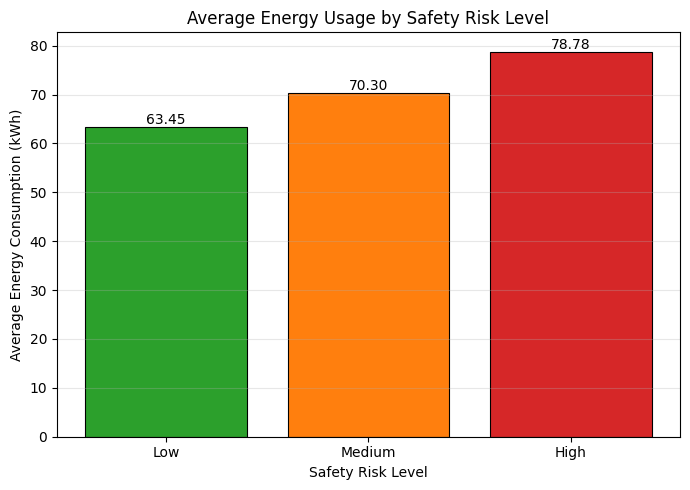

In [ ]:
df_plot = X_train.copy()
df_plot["energy_consumption_kwh"] = y_train.values
df_plot["risk_bin"] = pd.cut(
    df_plot["safety_risk_score"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
    )

energy_by_risk = df_plot.groupby("risk_bin", observed=True)["energy_consumption_kwh"].mean()

# Ensure consistent ordering
risk_order = ["Low", "Medium", "High"]
energy_by_risk = energy_by_risk.reindex(risk_order)

# Risk-aware colors
risk_colors = {
    "Low":    "#2ca02c",  # green
    "Medium": "#ff7f0e",  # orange
    "High":   "#d62728",  # red
}

plt.figure(figsize=(7, 5))

bars = plt.bar(
    energy_by_risk.index,
    energy_by_risk.values,
    color=[risk_colors[r] for r in energy_by_risk.index],
    edgecolor="black",
    linewidth=0.8
)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Safety Risk Level")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Usage by Safety Risk Level")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

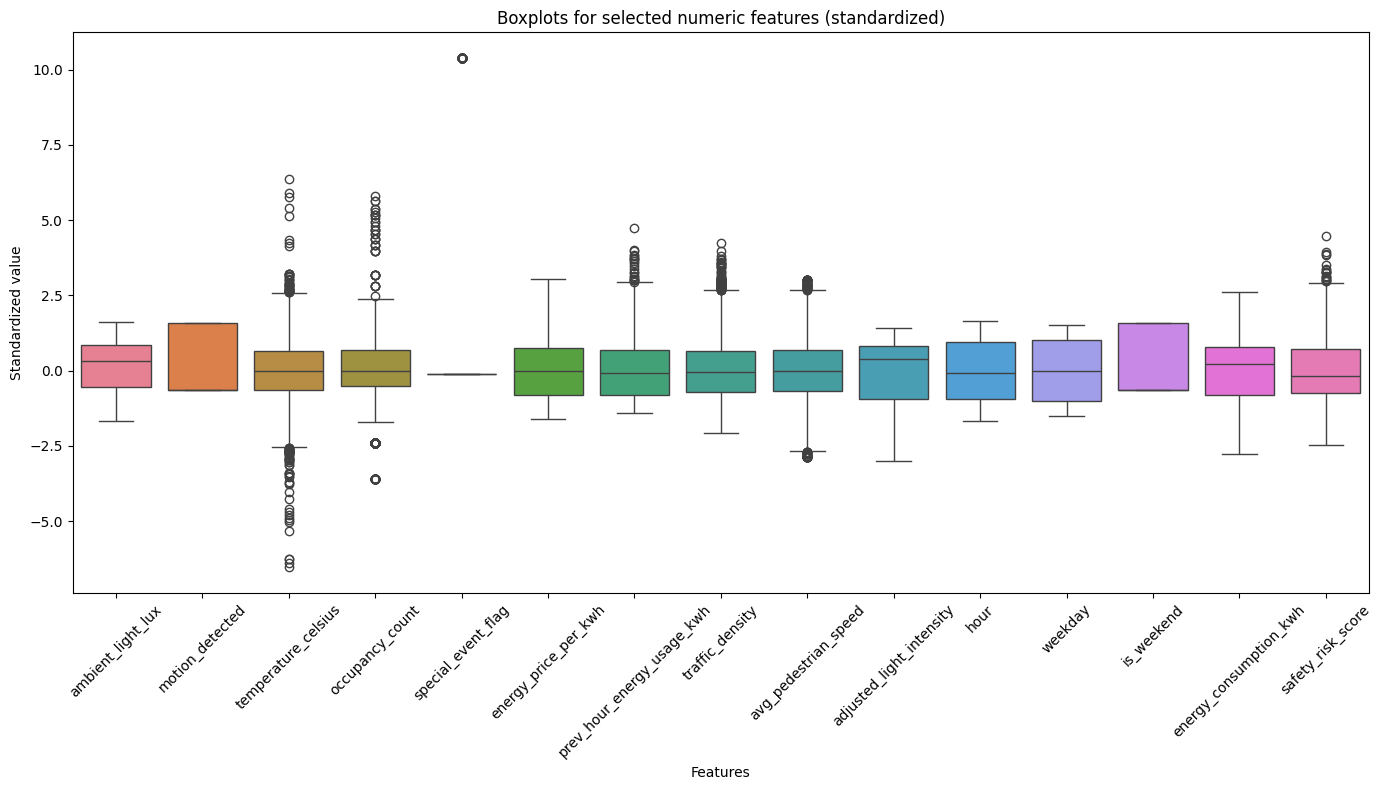

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

boxplot_features = [
    'ambient_light_lux',
    'motion_detected',
    'temperature_celsius',
    'occupancy_count',
    'special_event_flag',
    'energy_price_per_kwh',
    'prev_hour_energy_usage_kwh',
    'traffic_density',
    'avg_pedestrian_speed',
    'adjusted_light_intensity',
    'hour',
    'weekday',
    'is_weekend',
    'energy_consumption_kwh',
    'safety_risk_score'
]

# Prepare dataframe
df_for_boxplot = X_train.copy()
df_for_boxplot['adjusted_light_intensity'] = y_train.values

# Scale features
scaler = StandardScaler()
df_for_boxplot_scaled = pd.DataFrame(
    scaler.fit_transform(df_for_boxplot[boxplot_features]),
    columns=boxplot_features,
    index=df_for_boxplot.index
)

# Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_for_boxplot_scaled)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Standardized value")
plt.title("Boxplots for selected numeric features (standardized)")
plt.tight_layout()
plt.show()


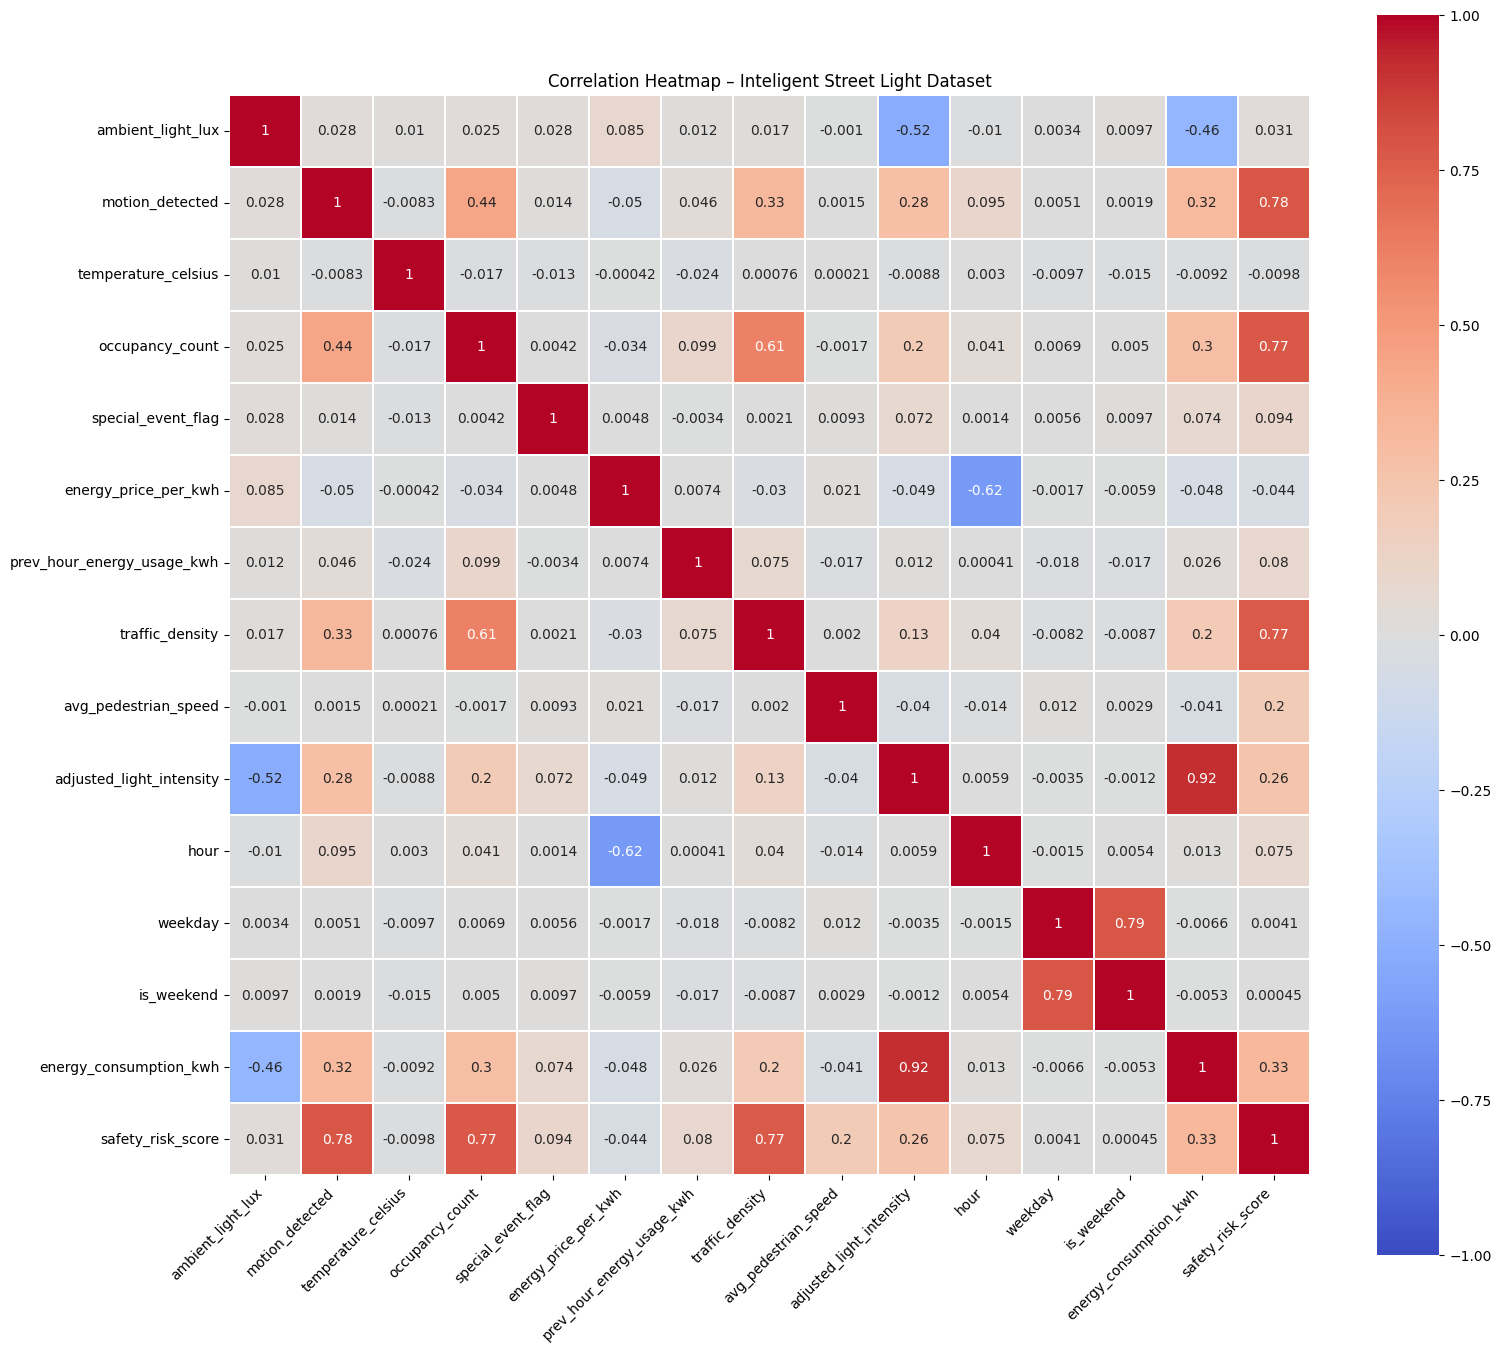

In [ ]:
heatmap_features = [
    'ambient_light_lux',
    'motion_detected',
    'temperature_celsius',
    'occupancy_count',
    'special_event_flag',
    'energy_price_per_kwh',
    'prev_hour_energy_usage_kwh',
    'traffic_density',
    'avg_pedestrian_speed',
    'adjusted_light_intensity',
    'hour',
    'weekday',
    'is_weekend',
    'energy_consumption_kwh',
    'safety_risk_score' # Re-adding this feature
]

# Create a DataFrame for the heatmap that includes both X_train and y_train (adjusted_light_intensity)
# Also include safety_risk_score which was added to X_train.
df_for_heatmap = X_train.copy()
df_for_heatmap['adjusted_light_intensity'] = y_train.values # Add the target variable back

corr = df_for_heatmap[heatmap_features].select_dtypes(include='number').corr(method='pearson')

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.3,
    square=True
)

plt.title("Correlation Heatmap – Inteligent Street Light Dataset")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------
##Simple **MLP** implementation with **Hyper-paramenters**
--------------------------------------------------------------------------------

In [ ]:
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, in_dim=28, hidden=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return F.softplus(self.net(x))

def get_optimizer(name, params, lr, momentum=0.9, weight_decay=0.0):
    """Return PyTorch optimizer instance based on name."""
    name = name.lower()
    # SGD variants
    if name == "sgd":
        return optim.SGD(params, lr=lr, weight_decay=weight_decay)
    if name == "momentum":
        return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)

    # Adaptive methods
    if name == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "amsgrad":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay, amsgrad=True)
    if name == "adagrad":
        return optim.Adagrad(params, lr=lr, weight_decay=weight_decay)
    if name == "adadelta":
        return optim.Adadelta(params, lr=lr, weight_decay=weight_decay)

    # Other advanced optimizers (requires torch_optimizer)
    if name == "nadam":
        return optim.NAdam(params, lr=lr, weight_decay=weight_decay)
    if name == "lion":
        return Lion(params, lr=lr, weight_decay=weight_decay)

    # RMSprop
    if name == "rmsprop":
        return optim.RMSprop(params, lr=lr, momentum=momentum, weight_decay=weight_decay)

    raise ValueError(f"Unknown optimizer: {name}")

In [ ]:
def train_and_eval(Xtr, Xte, ytr, yte, hparams, opt_name='adam', n_epochs=100, n_patience=30):
    start_time = time.time()
    in_dim = Xtr.shape[1]
    model = MLP(in_dim=in_dim, hidden=hparams["hidden_size"], dropout=hparams["dropout"])
    optimizer = get_optimizer(opt_name, model.parameters(), lr=hparams["lr"], momentum=hparams["momentum"], weight_decay=hparams["weight_decay"])

    criterion = nn.PoissonNLLLoss(log_input=False)

    losses = []
    rmse_trajectory = [] # New list to store RMSE per epoch

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=hparams["batch_size"], shuffle=True)

    best_loss = float("inf")
    if n_patience == -1: n_patience = n_epochs
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb).squeeze()
            loss = criterion(outputs, yb.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_loss = np.mean(batch_losses)
        losses.append(epoch_loss)

        # Calculate validation RMSE
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            y_pred_val = model(Xte).cpu().numpy().squeeze()
        val_rmse = np.sqrt(mean_squared_error(yte, y_pred_val))
        rmse_trajectory.append(val_rmse)

        val_loss = criterion(model(Xte).squeeze(1), yte.float()).item()
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= n_patience:
            break

        epochs_run = epoch + 1

    model.eval()
    with torch.no_grad():
        y_pred = model(Xte).cpu().numpy().squeeze()

    elapsed_time = time.time() - start_time

    metrics = {
        "RMSE": np.sqrt(mean_squared_error(yte, y_pred)),
        "MAE": mean_absolute_error(yte, y_pred),
        "R2": r2_score(yte, y_pred),
        "runtime": elapsed_time,
        "epochs": epochs_run
    }

    return model, metrics, losses, y_pred, rmse_trajectory

---

Example usage of the MLP baseline

---

In [ ]:
hp = {"lr": 1e-3, "momentum": 0.89, "hidden_size": 32, "weight_decay": 1e-4, "batch_size": 16, "dropout": 0.3}

In [ ]:
trained_model, metrics, losses, y_pred, _ = train_and_eval(Xtr, Xte, ytr, yte, hp, "nadam")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"R2:      {metrics['R2']:.4f}")
print(f"Runtime: {metrics['runtime']:.4f} sec")

RMSE:    8.2929
MAE:     6.5977
R2:      0.8633
Runtime: 65.5061 sec


In [ ]:
y_pred

array([88.42903 , 45.626205, 93.86494 , ..., 93.91739 , 34.85463 ,
       41.687996], dtype=float32)

---

# Creating Cumulative Energy Plots

---

In [ ]:
timestamps = df.loc[X_test.index, "timestamp"]

In [ ]:
temp_df = df.loc[X_test.index].copy() # Filter to test set rows
temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

temp_df = temp_df.sort_values(["zone_id", "timestamp"])

# Compute duration to next timestamp in hours
temp_df['duration_h'] = temp_df.groupby('zone_id')['timestamp'].shift(-1) - temp_df['timestamp']
temp_df['duration_h'] = temp_df['duration_h'].dt.total_seconds() / 3600

# Compute estimated P_MAX_ZONE per row
temp_df['P_MAX_ZONE_est'] = temp_df['energy_consumption_kwh'] / temp_df['duration_h'] * 100 / temp_df['adjusted_light_intensity']

# Filter out invalid rows (e.g., division by zero if adjusted_light_intensity is 0)
temp_df = temp_df[temp_df['adjusted_light_intensity'] > 0]

# Take the max across dataset
P_MAX_ZONE = temp_df['P_MAX_ZONE_est'].max()
print("Estimated P_MAX_ZONE (from calculation):", P_MAX_ZONE)

Estimated P_MAX_ZONE (from calculation): 4.244186046511628


In [ ]:
df_test = X_test.copy()
df_test["timestamp"] = pd.to_datetime(timestamps)
df_test["y_pred"] = y_pred
df_test['adjusted_light_intensity'] = y_test # Add the actual target values back

In [ ]:
df_test = df_test.sort_values("timestamp").reset_index(drop=True)

df_test["delta_hours"] = (df_test["timestamp"].diff().dt.total_seconds() / 3600)

# Drop first row (no valid interval)
df_test = df_test.dropna(subset=["delta_hours"])

In [ ]:
df_test["mlp_energy_kwh"] = (P_MAX_ZONE * df_test["y_pred"] / 100) * df_test["delta_hours"]

In [ ]:
df_test['baseline_energy_kwh'] = P_MAX_ZONE * (df_test['adjusted_light_intensity'] / 100) * df_test['delta_hours']

In [ ]:
daily = (df_test.set_index("timestamp")[["mlp_energy_kwh", "baseline_energy_kwh"]].resample("D").sum())

In [ ]:
daily["mlp_cum_kwh"] = daily["mlp_energy_kwh"].cumsum()
daily["baseline_cum_kwh"] = daily["baseline_energy_kwh"].cumsum()
daily["savings_cum_kwh"] = (daily["baseline_cum_kwh"] - daily["mlp_cum_kwh"])

In [ ]:
display(daily.head())

,mlp_energy_kwh,baseline_energy_kwh,mlp_cum_kwh,baseline_cum_kwh,savings_cum_kwh
timestamp,,,,,
2024-01-01,63.994464,66.891803,63.994464,66.891803,2.897338
2024-01-02,74.018113,73.673234,138.012577,140.565037,2.552460
2024-01-03,78.053798,76.345253,216.066375,216.910290,0.843915
2024-01-04,89.078778,95.647507,305.145153,312.557797,7.412645
2024-01-05,28.981318,27.255979,334.126471,339.813776,5.687305


---

## Daily cumulative energy (MLP vs baseline)

---

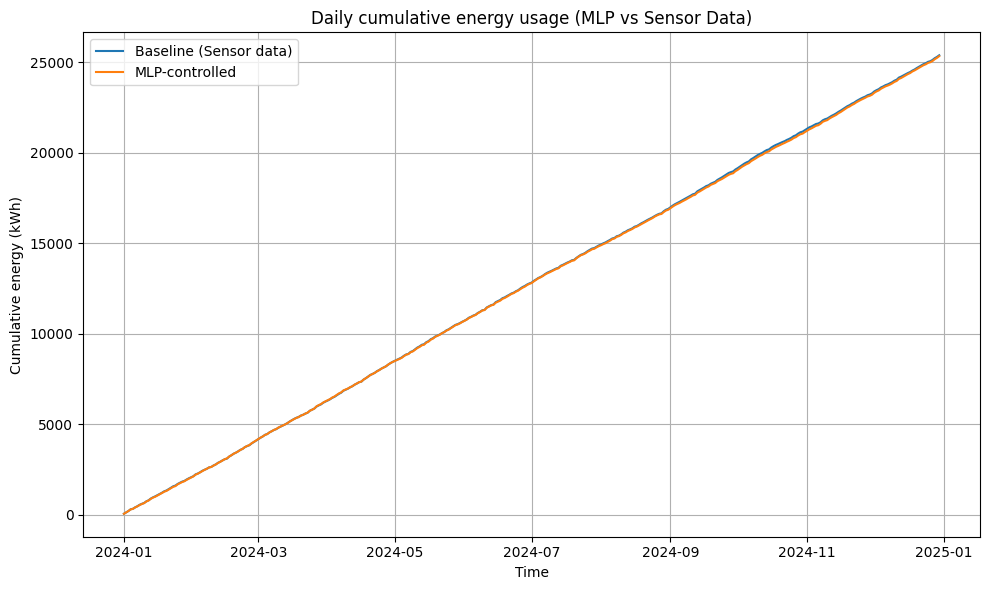

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(daily.index, daily["baseline_cum_kwh"], label="Baseline (Sensor data)")
plt.plot(daily.index, daily["mlp_cum_kwh"], label="MLP-controlled")

plt.title("Daily cumulative energy usage (MLP vs Sensor Data)")
plt.ylabel("Cumulative energy (kWh)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

## Cumulative energy savings

---

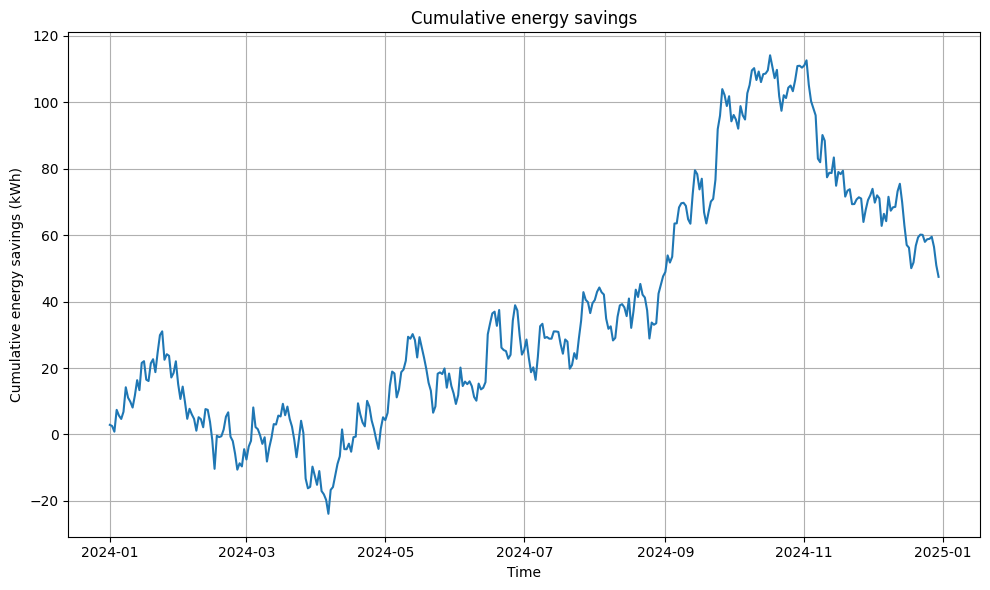

In [ ]:
plt.figure(figsize=(10, 6))

plt.title("Cumulative energy savings")
plt.plot(daily.index, daily["savings_cum_kwh"])
plt.ylabel("Cumulative energy savings (kWh)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

---

## Short-window hourly inspection

---

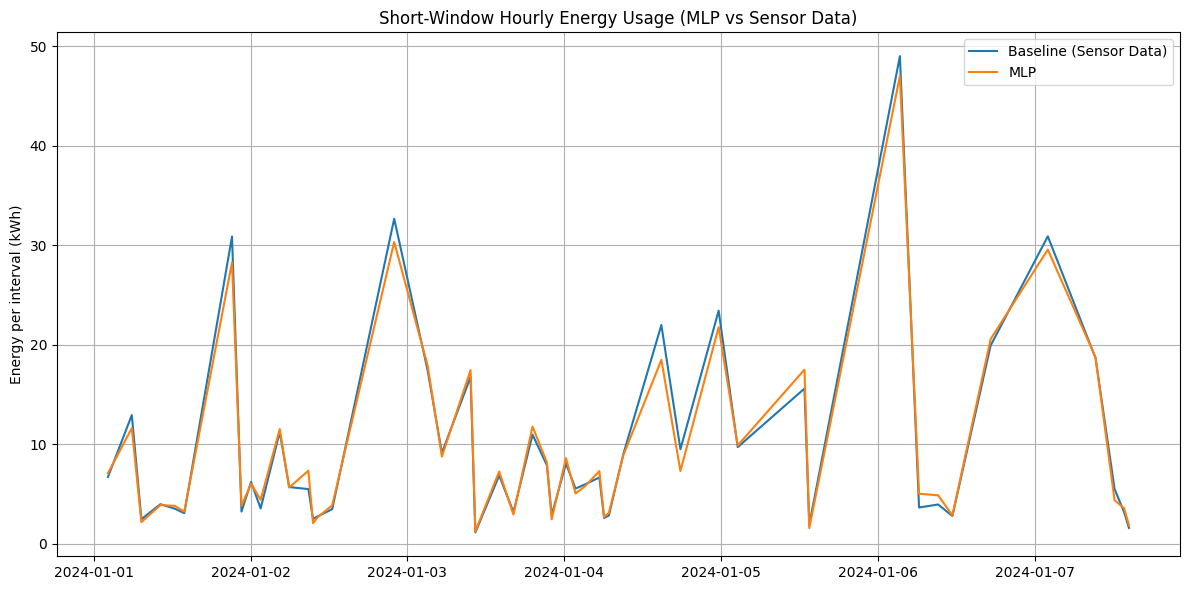

In [ ]:
window = 7 * 7 # approx one week worth of events

plt.figure(figsize=(12, 6))

plt.title("Short-Window Hourly Energy Usage (MLP vs Sensor Data)")
plt.plot(
    df_test["timestamp"][:window],
    df_test["baseline_energy_kwh"][:window],
    label="Baseline (Sensor Data)"
)

plt.plot(
    df_test["timestamp"][:window],
    df_test["mlp_energy_kwh"][:window],
    label="MLP"
)

plt.ylabel("Energy per interval (kWh)")
plt.legend()
plt.tight_layout()
plt.grid(which='both')
plt.show()

In [ ]:
total_baseline = daily["baseline_energy_kwh"].sum()
total_mlp = daily["mlp_energy_kwh"].sum()
savings_pct = 100 * (total_baseline - total_mlp) / total_baseline

print(f"Baseline energy: {total_baseline:.2f} kWh")
print(f"MLP energy: {total_mlp:.2f} kWh")
print(f"Savings: {savings_pct:.1f}%")

Baseline energy: 25376.58 kWh
MLP energy: 25329.16 kWh
Savings: 0.2%


---

### Some additional plots

---

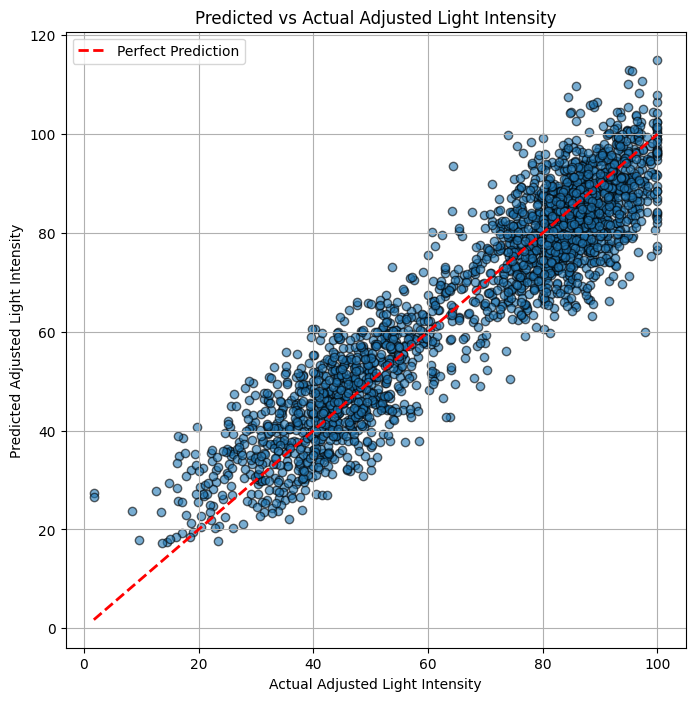

In [ ]:
y_true = yte.numpy() if isinstance(yte, torch.Tensor) else yte

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Adjusted Light Intensity')
plt.ylabel('Predicted Adjusted Light Intensity')
plt.title('Predicted vs Actual Adjusted Light Intensity')
plt.legend()
plt.grid(True)
plt.show()

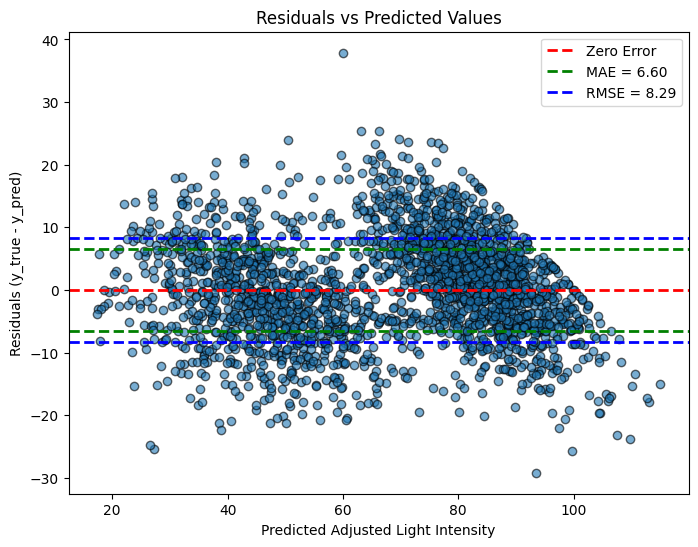

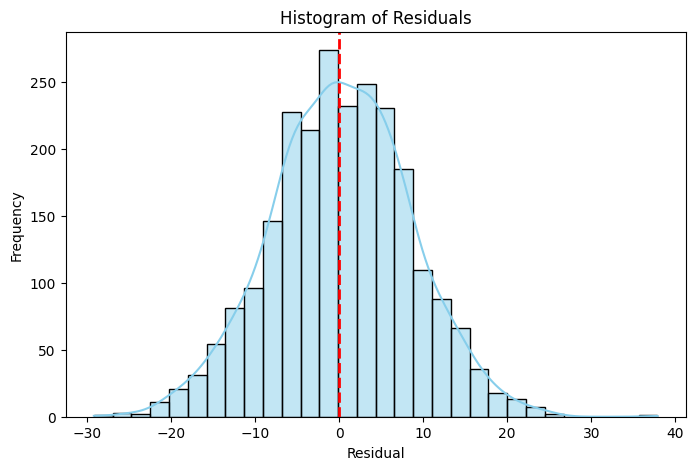

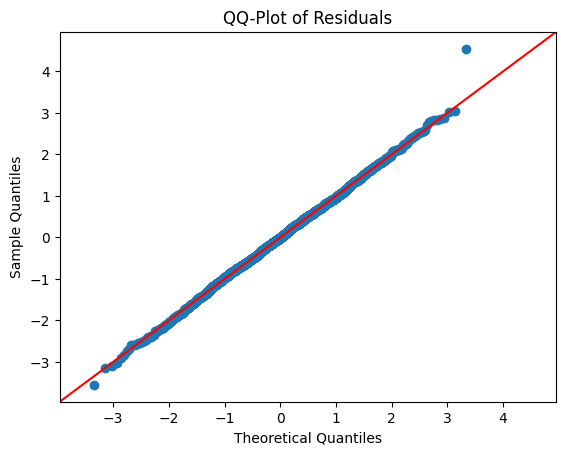

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure y_true is a 1D numpy array
y_true = yte.numpy().flatten() if isinstance(yte, torch.Tensor) else yte.flatten()
# Ensure y_pred is a 1D numpy array
y_pred = y_pred.flatten()

residuals = y_true - y_pred

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

# Scatter plot of residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k')
plt.axhline(0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.axhline(mae, color='g', linestyle='--', lw=2, label=f'MAE = {mae:.2f}')
plt.axhline(-mae, color='g', linestyle='--', lw=2)
plt.axhline(rmse, color='b', linestyle='--', lw=2, label=f'RMSE = {rmse:.2f}')
plt.axhline(-rmse, color='b', linestyle='--', lw=2)
plt.xlabel('Predicted Adjusted Light Intensity')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Residuals vs Predicted Values')
plt.legend()
plt.show()

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.axvline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

# Optional: QQ-plot to check normality/skewness
import scipy.stats as stats
import statsmodels.api as sm

sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ-Plot of Residuals')
plt.show()

---

### Testing which optimizers gets the best results. The best are:
- **Adam**
- NAdam

---

In [ ]:
optimizers = ["sgd", "momentum", "adam", "amsgrad", "adagrad", "adadelta", "nadam", "lion", "rmsprop"]

results = []

for opt_name in optimizers:
    _, metrics, losses, _, _ = train_and_eval(Xtr, Xte, ytr, yte, hp, opt_name, n_epochs=100, n_patience=-1)
    results.append({
        "Optimizer": opt_name,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "Runtime_sec": metrics["runtime"]
    })

df_results = pd.DataFrame(results)

print(df_results)

  Optimizer       RMSE        MAE        R2  Runtime_sec
0       sgd   8.388734   6.647504  0.860171    42.564271
1  momentum   8.280605   6.576911  0.863752    48.416042
2      adam   8.326262   6.616537  0.862246    96.608398
3   amsgrad   8.596186   6.831743  0.853169    53.757409
4   adagrad  61.484016  58.038685 -6.511548    50.235032
5  adadelta  66.831499  63.152969 -7.874980    54.579970
6     nadam   8.234646   6.525569  0.865261    56.183558
7      lion   8.393412   6.619391  0.860015    49.773278
8   rmsprop   8.603209   6.801264  0.852929    60.790396


---

### Testing the performance of some scikit-learn library baselines. The best are:
- **XGB**
- GradientBoosting

---

In [ ]:
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Define all models
models = [
    ("XGB", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,

    )),
    ("Ridge", Ridge(alpha=1.0)),
    ("Lasso", Lasso(alpha=0.01)),
    ("ElasticNet", ElasticNet(alpha=0.01, l1_ratio=0.5)),
    ("RandomForest", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,

    )),
    ("GradientBoosting", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,

    )),
]

In [ ]:
def model_eval(model, Xtr, Xte, ytr, yte, param = {}):
    ytr = ytr.ravel()
    yte = yte.ravel()

    start_time = time.time()
    model.fit(Xtr, ytr)
    elapsed_time = time.time() - start_time

    y_pred = model.predict(Xte)

    metrics = {
        "RMSE": np.sqrt(mean_squared_error(yte, y_pred)),
        "MAE": mean_absolute_error(yte, y_pred),
        "R2": r2_score(yte, y_pred),
        "Runtime": elapsed_time
    }
    return metrics

In [ ]:
results_list = []

for name, model in models:
    result = {"RMSE": [], "MAE": [], "R2": [], "Runtime": []}

    for _ in range(20):  # 20 runs
        metrics = model_eval(model, Xtr, Xte, ytr, yte)
        result["RMSE"].append(metrics["RMSE"])
        result["MAE"].append(metrics["MAE"])
        result["R2"].append(metrics["R2"])
        result["Runtime"].append(metrics["Runtime"])

    results_list.append({
        "Model": name,
        "RMSE": f"{np.mean(result['RMSE']):.4f} ± {np.std(result['RMSE']):.4f}",
        "MAE": f"{np.mean(result['MAE']):.4f} ± {np.std(result['MAE']):.4f}",
        "R2": f"{np.mean(result['R2']):.4f} ± {np.std(result['R2']):.4f}",
        "Runtime_sec": f"{np.mean(result['Runtime']):.4f} ± {np.std(result['Runtime']):.4f} sec"
    })

df_results = pd.DataFrame(results_list)
print(df_results)

              Model             RMSE              MAE               R2  \
0               XGB  7.2377 ± 0.0000  5.6065 ± 0.0000  0.8959 ± 0.0000   
1             Ridge  8.3433 ± 0.0000  6.6273 ± 0.0000  0.8617 ± 0.0000   
2             Lasso  8.3482 ± 0.0000  6.6334 ± 0.0000  0.8615 ± 0.0000   
3        ElasticNet  8.3473 ± 0.0000  6.6332 ± 0.0000  0.8616 ± 0.0000   
4      RandomForest  7.2638 ± 0.0058  5.5745 ± 0.0044  0.8952 ± 0.0002   
5  GradientBoosting  7.2361 ± 0.0006  5.5834 ± 0.0006  0.8960 ± 0.0000   

            Runtime_sec  
0   0.4245 ± 0.0969 sec  
1   0.0033 ± 0.0028 sec  
2   0.0910 ± 0.0057 sec  
3   0.1034 ± 0.0035 sec  
4  13.1002 ± 0.1436 sec  
5   9.0918 ± 0.1526 sec  


## Fuzzy rules + MLP

In [ ]:
# IMPORTANT! Check the data inside the saved DataFrame
df_fuzzy.describe()

,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,traffic_density,avg_pedestrian_speed,adjusted_light_intensity,energy_consumption_kwh,hour,weekday,month,is_weekend
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,3708.629288,0.284083,24.964518,8.557167,0.008583,5.034449,2.545444,22.048175,2.929889,68.204271,1.483592,11.498083,2.992583,6.498583,0.285000
std,4656.283063,0.450996,6.260797,8.273770,0.092252,1.272504,1.811987,10.585009,1.014598,22.314649,0.538188,6.922475,2.003088,3.444390,0.451433
min,0.000000,0.000000,-15.870000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.720000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,55.565000,0.000000,20.970000,5.000000,0.000000,4.000000,1.090000,14.600000,2.250000,47.345000,1.047000,5.000000,1.000000,4.000000,0.000000
50%,2031.855000,0.000000,24.970000,7.000000,0.000000,5.010000,2.430000,21.500000,2.930000,76.690000,1.595000,11.000000,3.000000,7.000000,0.000000
75%,7011.792500,1.000000,29.082500,11.000000,0.000000,5.990000,3.800000,28.800000,3.610000,86.650000,1.907000,17.000000,5.000000,9.000000,1.000000
max,105403.500000,1.000000,64.860000,230.000000,1.000000,8.910000,11.120000,67.100000,6.000000,100.000000,2.887000,23.000000,6.000000,12.000000,1.000000


In [ ]:
hp = {'lr': 0.01067285461914955, 'momentum': 0.9373390496116293, 'hidden_size': 32, 'weight_decay': 0.0011520037410809015, 'batch_size': 64, "dropout": 0.3}
trained_model, metrics, losses, y_pred, _ = train_and_eval(Xtr, Xte, ytr, yte, hp, "adam")
metrics

{'RMSE': np.float64(8.536226602651572),
 'MAE': 6.800439357757568,
 'R2': 0.855210542678833,
 'runtime': 21.488720893859863,
 'epochs': 61}

---

Functions for determining the **activity**, **ambient** and **visibility**

---

In [ ]:
def activity_level(y_pred, hp):
    if y_pred < hp["activity_low"]:
        return "low"
    elif y_pred < hp["activity_medium"]:
        return "medium"
    else:
        return "high"

def visibility_level(df_row):
    hour = df_row['hour']
    is_foggy = df_row['weather_condition_Foggy']
    is_rainy = df_row['weather_condition_Rainy']
    is_cloudy = df_row['weather_condition_Cloudy']

    if is_foggy or is_rainy:
        return "poor"

    if hour < 6 or hour > 20:
        return "poor"

    if is_cloudy:
        return "normal"

    return "good"

def ambient_level(lux, hp):
    if lux < hp["ambient_dark"]:
        return "dark"
    elif lux < hp["ambient_dim"]:
        return "dim"
    elif lux < hp["ambient_bright"]:
        return "normal"
    else:
        return "very_bright"

In [ ]:
def fuzzy_lighting(y_pred, visibility, df_row, hp):
    # Initialize
    output = y_pred
    delta = 0.0

    # --- Compute ambient and activity levels ---
    ambient = ambient_level(df_row['ambient_light_lux'], hp)
    activity = activity_level(y_pred, hp)

    # --- Visibility adjustment (smooth) ---
    if visibility == "poor":
        delta += 2.0 * (1 - y_pred / 100)  # larger boost if prediction is low
    elif visibility == "good":
        delta -= 1.5 * (y_pred / 100)  # reduce more if prediction is high

    # --- Ambient adjustment ---
    if ambient == "dark":
        delta += 1.5
    elif ambient == "very_bright":
        delta -= 1.5

    # --- Activity adjustment ---
    if activity == "high" and visibility != "good":
        delta += 1.0
    elif activity == "low" and visibility == "good":
        delta -= 1.0

    # # --- Apply bounded residual correction ---
    delta = np.clip(delta, -hp["max_delta"], hp["max_delta"])
    output += hp["alpha"] * delta

    # --- No hard safety enforcement here ---
    return float(np.clip(output, 0.0, 100.0))

---

To find the optimal thresholds for each fuzzy rule I applied an objective function with OPTUNA and tried to achieve as best results as I could.   

##### From what I tested this sh*t just straight up doesn't work and probably needs more thought put into it, because of how small the actual impact is of the fuzzy rules on the predictions.
---

In [ ]:
def objective(trial):
    hp = {
        "ambient_dark": trial.suggest_float("ambient_dark", 0, 200),
        "ambient_dim": trial.suggest_float("ambient_dim", 200, 3000),
        "ambient_bright": trial.suggest_float("ambient_bright", 3000, 15000),

        "activity_low": trial.suggest_float("activity_low", 0, 15),
        "activity_medium": trial.suggest_float("activity_medium", 15, 40),

        "alpha": trial.suggest_float("alpha", 0.01, 0.7, log=True),
        "max_delta": trial.suggest_float("max_delta", 0.5, 8.0, log=True),
    }

    y_pred_flat = (
        y_pred.flatten()
        if isinstance(y_pred, np.ndarray) and y_pred.ndim > 1
        else y_pred
    )

    fuzzy_preds = []
    for i in range(len(y_pred_flat)):
        # For each entry in the prediction array we apply the fuzzy rule
        vis = visibility_level(df_fuzzy.iloc[i])
        fuzzy_preds.append(fuzzy_lighting(y_pred_flat[i], vis, df_fuzzy.iloc[i], hp))
    fuzzy_preds = np.array(fuzzy_preds)

    rmse = np.sqrt(mean_squared_error(yte, fuzzy_preds))
    mae = mean_absolute_error(yte, fuzzy_preds)
    r2 = r2_score(yte, fuzzy_preds)

    trial.set_user_attr("R2", r2)
    trial.set_user_attr("RMSE", rmse)
    trial.set_user_attr("MAE", mae)

    # I used this objective, because of the staggering
    # value of RMSE but didn't helped :'(
    return 0.7 * rmse + 0.3 * mae

---

The **Hyperband** and **TPESampler** where used to search for optimal fuzzy thresholds

---

In [ ]:
study = optuna.create_study(
        direction="minimize",
        pruner=HyperbandPruner()
)
study.optimize(objective, n_trials=200)
print("\n======= BEST TRIAL PARAMETERS =======\n")
print(f"Parameters: {study.best_params}")
print(f"Best Value: {study.best_value:.4f}")
print(f"MAE: {study.best_trial.user_attrs['MAE']:.4f}, R2: {study.best_trial.user_attrs['R2']:.4f}, RMSE: {study.best_trial.user_attrs['RMSE']:.4f}")

[I 2026-01-17 11:57:55,349] A new study created in memory with name: no-name-5d45bb9a-609a-4098-930f-643d01694686
[I 2026-01-17 11:57:55,634] Trial 0 finished with value: 7.89905223976618 and parameters: {'ambient_dark': 120.88573227902188, 'ambient_dim': 205.21263033853842, 'ambient_bright': 3460.720402773261, 'activity_low': 1.5710490957850194, 'activity_medium': 37.24358717482401, 'alpha': 0.029643914775779143, 'max_delta': 2.8165403214907836}. Best is trial 0 with value: 7.89905223976618.
[I 2026-01-17 11:57:55,897] Trial 1 finished with value: 7.951897211618526 and parameters: {'ambient_dark': 63.807817666361274, 'ambient_dim': 651.6718355626108, 'ambient_bright': 4406.064843456426, 'activity_low': 0.9675649423171007, 'activity_medium': 19.947225135570267, 'alpha': 0.4938954059093996, 'max_delta': 7.005245949644331}. Best is trial 0 with value: 7.89905223976618.
[I 2026-01-17 11:57:56,159] Trial 2 finished with value: 7.898638996870608 and parameters: {'ambient_dark': 103.02196564


======= BEST TRIAL PARAMETERS =======

Parameters: {'ambient_dark': 95.22547525088439, 'ambient_dim': 760.7848510752789, 'ambient_bright': 13742.02130325675, 'activity_low': 10.39140817900563, 'activity_medium': 24.324132151340372, 'alpha': 0.4155745271249882, 'max_delta': 3.0012744490318344}
Best Value: 7.8683
MAE: 6.6700, R2: 0.8604, RMSE: 8.3819


In [ ]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler()
)
study.optimize(objective, n_trials=200)
print("\n======= BEST TRIAL PARAMETERS =======\n")
print(f"Parameters: {study.best_params}")
print(f"Best Value: {study.best_value:.4f}")
print(f"MAE: {study.best_trial.user_attrs['MAE']:.4f}, R2: {study.best_trial.user_attrs['R2']:.4f}, RMSE: {study.best_trial.user_attrs['RMSE']:.4f}")

[I 2026-01-17 11:58:57,060] A new study created in memory with name: no-name-8620c5da-2214-4e84-897e-c1f7d49457d7
[I 2026-01-17 11:58:57,349] Trial 0 finished with value: 7.893600252159693 and parameters: {'ambient_dark': 39.995368100766626, 'ambient_dim': 1305.2374301506488, 'ambient_bright': 14369.316536793507, 'activity_low': 9.893051738523862, 'activity_medium': 35.5259720931918, 'alpha': 0.6449662538791986, 'max_delta': 1.0545111162205283}. Best is trial 0 with value: 7.893600252159693.
[I 2026-01-17 11:58:57,620] Trial 1 finished with value: 7.898055451424884 and parameters: {'ambient_dark': 102.31727091248007, 'ambient_dim': 633.0189562886183, 'ambient_bright': 9145.0960350451, 'activity_low': 14.874671065695567, 'activity_medium': 22.628839691270308, 'alpha': 0.014204407807573281, 'max_delta': 1.2703387261091001}. Best is trial 0 with value: 7.893600252159693.
[I 2026-01-17 11:58:57,910] Trial 2 finished with value: 7.88840769650707 and parameters: {'ambient_dark': 86.812004950


======= BEST TRIAL PARAMETERS =======

Parameters: {'ambient_dark': 184.85290181951248, 'ambient_dim': 2425.926858630043, 'ambient_bright': 12567.331296320302, 'activity_low': 11.96375383058937, 'activity_medium': 20.157013255639868, 'alpha': 0.42953379685403054, 'max_delta': 3.0110363937067657}
Best Value: 7.8665
MAE: 6.6672, R2: 0.8604, RMSE: 8.3804


---

# Simple Evolutionary Algorithm - It's only optimizing the Fuzzy Search Space.

Actually better then the previous algorithms.

---

In [ ]:
BOUNDS = {
    "ambient_dark": (0, 200),
    "ambient_dim": (200, 3000),
    "ambient_bright": (3000, 15000),
    "activity_low": (0, 15),
    "activity_medium": (15, 40),
    "alpha": (0.01, 0.7),
    "max_delta": (0.5, 10.0),
}

In [ ]:
def fitness(individual):
    # Convert genome to hp dict
    hp = dict(zip(BOUNDS.keys(), individual))

    y_pred_flat = y_pred.flatten() if y_pred.ndim > 1 else y_pred
    fuzzy_preds = np.array([
        fuzzy_lighting(y_pred_flat[i], visibility_level(df_fuzzy.iloc[i]), df_fuzzy.iloc[i], hp)
        for i in range(len(y_pred_flat))
    ])

    rmse = np.sqrt(mean_squared_error(yte, fuzzy_preds))
    mae = mean_absolute_error(yte, fuzzy_preds)
    r2 = r2_score(yte, fuzzy_preds)

    return rmse, mae, r2  # return all metrics

In [ ]:
import random
import numpy as np

def random_individual():
    return np.array([
        random.uniform(*BOUNDS[k]) for k in BOUNDS
    ])

def init_population(pop_size=30):
    return [random_individual() for _ in range(pop_size)]

In [ ]:
def tournament_selection(pop, fitnesses, k=3):
    selected = random.sample(list(zip(pop, fitnesses)), k)
    return min(selected, key=lambda x: x[1])[0]

In [ ]:
def crossover(parent1, parent2, alpha=0.5):
    child = alpha * parent1 + (1 - alpha) * parent2
    return child

In [ ]:
def mutate(individual, sigma=0.1, p=0.2):
    for i, key in enumerate(BOUNDS):
        if random.random() < p:
            low, high = BOUNDS[key]
            individual[i] += np.random.normal(0, sigma * (high - low))
            individual[i] = np.clip(individual[i], low, high)
    return individual

In [ ]:
def evolve(generations=50, pop_size=30, elite_frac=0.2):
    pop = init_population(pop_size)

    best_history = []  # Store metrics per generation

    for gen in range(generations):
        metrics = [fitness(ind) for ind in pop]
        fitnesses = [m[0] for m in metrics]  # RMSE for selection

        # Elitism
        elite_count = int(elite_frac * pop_size)
        elite_idx = np.argsort(fitnesses)[:elite_count]
        new_pop = [pop[i] for i in elite_idx]

        # Generate offspring
        while len(new_pop) < pop_size:
            p1 = tournament_selection(pop, fitnesses)
            p2 = tournament_selection(pop, fitnesses)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        pop = new_pop

        # Store best metrics this generation
        best_idx = np.argmin(fitnesses)
        best_rmse, best_mae, best_r2 = metrics[best_idx]
        best_history.append((best_rmse, best_mae, best_r2))
        print(f"Gen {gen:03d} | RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | R2: {best_r2:.4f}")

    # Final best
    final_metrics = [fitness(ind) for ind in pop]
    best_idx = np.argmin([m[0] for m in final_metrics])
    best_individual = pop[best_idx]
    best_rmse, best_mae, best_r2 = final_metrics[best_idx]

    return best_individual, best_rmse, best_mae, best_r2, best_history

In [ ]:
best_individual, best_rmse, best_mae, best_r2, best_history = evolve(
    generations=50,    # number of generations
    pop_size=100,       # population size
    elite_frac=0.2     # fraction of elite individuals retained each generation
)

print("Best hyperparameters:", dict(zip(BOUNDS.keys(), best_individual)))
print("Best RMSE:", best_rmse)
print("Best MAE:", best_mae)
print("Best R2:", best_r2)

---

## QuantumSAGE EA + Optimization of Energy vs Safety

Attempt at creating the EA that will optimize the safety + energy usage or whatever that f*cking means. It's also staggering after few trials, needs more refinement.

---

In [ ]:
X_columns = X_train.columns.values

In [ ]:
fuzzy_hp = {'ambient_dark': 184.85290181951248, 'ambient_dim': 2425.926858630043, 'ambient_bright': 12567.331296320302, 'activity_low': 11.96375383058937, 'activity_medium': 20.157013255639868, 'alpha': 0.42953379685403054, 'max_delta': 3.0110363937067657}

In [ ]:
def build_mlp_features(candidates, df_eval, device):
    MAX_LUX = float(df_fuzzy['ambient_light_lux'].mean())
    rows = []

    for _, row in df_eval.iterrows():
        hour = int(row["hour_block"])
        light_percent = candidates[hour]
        ambient_lux = (light_percent / 100.0) * MAX_LUX

        # build feature row in order of X_train
        row_features = [
            ambient_lux,
            row['motion_detected'],
            row['temperature_celsius'],
            row['occupancy_count'],
            row['special_event_flag'],
            row['energy_price_per_kwh'],
            row['prev_hour_energy_usage_kwh'],
            row['traffic_density'],
            row['avg_pedestrian_speed'],
            row['energy_consumption_kwh'],
            row['hour'],
            row['weekday'],
            row['month'],
            row['is_weekend'],
            *[row[f'zone_id_{i}'] for i in range(1, 13)],
            row['weather_condition_Clear'],
            row['weather_condition_Cloudy'],
            row['weather_condition_Foggy'],
            row['weather_condition_Rainy'],
            row['time_of_day_Afternoon'],
            row['time_of_day_Evening'],
            row['time_of_day_Morning'],
            row['time_of_day_Night'],
            row['safety_risk_score']
        ]

        rows.append(row_features)

    return torch.tensor(rows, dtype=torch.float32, device=device)

In [ ]:
import random
import numpy as np
from scipy.stats import qmc

# --- Sobol sampling for initialization ---
def sobol_sampling(n, dim, lb, ub):
    sampler = qmc.Sobol(d=dim, scramble=True)
    m = int(np.ceil(np.log2(n)))
    samples = sampler.random_base2(m=m)[:n]
    return lb + (ub - lb) * samples

# --- Multi-objective fitness function ---
def mo_fitness_hybrid(candidates, df_eval, mlp_model, device, fuzzy_hp, alpha=1.0):
    """
    candidates: array of size [n_hour_blocks], values in [0, 100]
    """

    adjusted_lighting = []
    total_energy = 0.0

    for _, row in df_eval.iterrows():
        h = row["hour_block"]

        # --- Context inference ---
        visibility = visibility_level(row)

        # --- Fuzzy lighting adjustment ---
        y_fuzzy = fuzzy_lighting(
            y_pred=candidates[h],
            visibility=visibility,
            df_row=row,
            hp=fuzzy_hp
        )

        adjusted_lighting.append(y_fuzzy)

        # --- Energy calculation ---
        total_energy += (
            P_MAX_ZONE * y_fuzzy / 100.0 * row["delta_hours"]
        )

    avg_energy = total_energy / len(df_eval)

    # --- Violation prediction using fuzzy-adjusted lighting ---
    mlp_model.eval()
    with torch.no_grad():
        X = build_mlp_features(
            np.array(adjusted_lighting),
            df_eval,
            device
        )
        pred_violation = mlp_model(X).mean().item()

    return avg_energy, pred_violation

def safety_score(row, visibility, light):
    risk = 0.0
    if visibility == "poor":
        risk += 0.4
    if row["traffic_density"] > 30:
        risk += 0.3
    if row["occupancy_count"] >= 5:
        risk += 0.3
    min_light = 30 + 40 * risk
    return 1.0 if light >= min_light else light / min_light

class Simple_DE_MO:
    def __init__(self, pop_size=50, F=0.8, CR=0.9, max_generations=50):
        self.pop_size = pop_size
        self.F = F
        self.CR = CR
        self.max_generations = max_generations

    def __call__(self, fitness_fn, lb, ub, df_eval):
        dim = len(lb)

        # 1. Initialize population using Sobol sampling
        pop = sobol_sampling(self.pop_size, dim, lb, ub)

        # 2. Evaluate fitness of the initial population
        fitness = np.array([fitness_fn(ind, df_eval) for ind in pop])

        for gen in range(self.max_generations):
            for i in range(self.pop_size):
                # 3. Mutation: DE/rand/1/bin strategy
                idxs = [j for j in range(self.pop_size) if j != i]
                r1, r2, r3 = np.random.choice(idxs, 3, replace=False)

                mutant = pop[r1] + self.F * (pop[r2] - pop[r3])
                mutant = np.clip(mutant, lb, ub) # Ensure bounds are respected

                # 4. Crossover
                j_rand = random.randrange(dim)
                mask = np.random.rand(dim) < self.CR
                # Ensure at least one element comes from the mutant
                if not np.any(mask):
                    mask[j_rand] = True
                trial = np.where(mask, mutant, pop[i])

                # 5. Evaluate fitness of the trial vector
                trial_fitness = fitness_fn(trial, df_eval)

                # 6. Selection: Pareto dominance
                # Assuming fitness_fn returns two objectives (obj1, obj2)
                # We want to minimize both obj1 and obj2
                current_obj1, current_obj2 = fitness[i]
                trial_obj1, trial_obj2 = trial_fitness

                # Trial dominates current if it's better or equal on all objectives
                # AND strictly better on at least one objective
                dominates = ((trial_obj1 <= current_obj1 and trial_obj2 <= current_obj2) and
                             (trial_obj1 < current_obj1 or trial_obj2 < current_obj2))

                if dominates:
                    pop[i] = trial
                    fitness[i] = trial_fitness

            if gen % 10 == 0:
                print(f"Generation {gen} | Sample fitness (first individual): {fitness[0]}")

        # 7. Extract Pareto front
        pareto_mask = np.ones(self.pop_size, dtype=bool)
        for i in range(self.pop_size):
            for j in range(self.pop_size):
                if i != j:
                    # Check if individual j dominates individual i
                    if ((fitness[j][0] <= fitness[i][0] and fitness[j][1] <= fitness[i][1]) and
                        (fitness[j][0] < fitness[i][0] or fitness[j][1] < fitness[i][1])):
                        pareto_mask[i] = False
                        break

        return pop[pareto_mask], fitness[pareto_mask]

In [ ]:
hp = {'lr': 0.007861615941676454, 'momentum': 0.831506713103715, 'hidden_size': 32, 'weight_decay': 0.00011851096201963328, 'batch_size': 64, 'dropout': 0.10714970673736593} # After Optimizing TPE
trained_model, metrics, losses, y_pred, _ = train_and_eval(Xtr, Xte, ytr, yte, hp, "adam")

In [ ]:
df_for_de_eval = df_test.copy()
df_for_de_eval["hour_block"] = df_for_de_eval["hour"]

# The optimization space for light intensity is for all 24 hours (0-23)
n_hours = 24
hour_blocks = list(range(n_hours)) # This represents the candidate structure

lb = np.zeros(n_hours)       # 0% min light
ub = np.ones(n_hours) * 100  # 100% max light

device = next(trained_model.parameters()).device

de = Simple_DE_MO()

# Define the desired safety threshold
desired_safety_threshold = 0.7

pareto_solutions, pareto_fitness = de(
    fitness_fn=lambda c, d: mo_fitness_hybrid(
        c, d, trained_model, device, fuzzy_hp, alpha=0.7
    ),
    lb=lb,
    ub=ub,
    df_eval=df_for_de_eval # Use the prepared DataFrame
)

# Pick safety-first solution
# The second objective (obj2) is the pred_violation, so we want to minimize it.
# It also includes the penalty, so minimizing it will lead to higher safety.
safe_idx = np.argmin([f[1] for f in pareto_fitness])
best_solution = pareto_solutions[safe_idx]
best_energy, best_safety = pareto_fitness[safe_idx]

print("Best zone light % settings:", best_solution)
print("Energy:", best_energy)
print("Safety:", best_safety)

Generation 0 | Sample fitness (first individual): [   6.61296605 5869.52783203]
Generation 10 | Sample fitness (first individual): [   5.01813087 4042.43188477]
Generation 20 | Sample fitness (first individual): [   3.95118518 2420.03540039]
Generation 30 | Sample fitness (first individual): [   3.95118518 2420.03540039]
Generation 40 | Sample fitness (first individual): [   3.4356529  1384.14428711]
Best zone light % settings: [  0.           0.           0.          42.49251502  17.69085485
   0.          32.96298866  21.46242019   0.          21.34596793
   2.48883376   8.47173571   4.50989556   2.91295476   0.
   0.           0.          41.33765271 100.           0.
  10.35362482   0.           0.          66.21320123]
Energy: 2.526949716391505
Safety: 872.6051635742188


In [ ]:
df_plot = df_for_de_eval.copy()
df_plot.to_csv(root_dir + "OptimizedDataPlot.csv")

In [ ]:
# df must have 'hour_block' column
df_plot['optimized_light_percent'] = best_solution[df_plot['hour_block'].astype(int)]

In [ ]:
# Optimized energy
df_plot['optimized_energy_kwh'] = P_MAX_ZONE * df_plot['optimized_light_percent'] / 100 * df_plot['delta_hours']

# Baseline energy (from sensor-adjusted intensity)
df_plot['baseline_energy_kwh'] = P_MAX_ZONE * df_plot['adjusted_light_intensity'] / 100 * df_plot['delta_hours']

# Cumulative sums
df_plot['optimized_cum_kwh'] = df_plot['optimized_energy_kwh'].cumsum()
df_plot['baseline_cum_kwh'] = df_plot['baseline_energy_kwh'].cumsum()

# Cumulative savings
df_plot['savings_cum_kwh'] = df_plot['baseline_cum_kwh'] - df_plot['optimized_cum_kwh']

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_plot['timestamp'], df_plot['baseline_cum_kwh'], label='Baseline (Sensor data)')
plt.plot(df_plot['timestamp'], df_plot['optimized_cum_kwh'], label='EA+MLP+Fuzzy Optimized')
plt.fill_between(df_plot['timestamp'], df_plot['optimized_cum_kwh'], df_plot['baseline_cum_kwh'], color='green', alpha=0.2, label='Energy Savings')
plt.title('Daily Cumulative Energy Usage: Optimized vs Baseline')
plt.xlabel('Time')
plt.ylabel('Cumulative Energy (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
total_baseline = df_plot["baseline_cum_kwh"].iloc[-1]
total_optimized = df_plot["optimized_cum_kwh"].iloc[-1]
energy_saving_pct = 100 * (total_baseline - total_optimized) / total_baseline

print(f"Total energy savings: {energy_saving_pct:.2f}%")

In [ ]:
window = 7 * 14  # approx one week

plt.figure(figsize=(12, 6))
plt.title("Short-Window Hourly Energy Usage (Optimized vs Baseline)")

x = df_plot["timestamp"][:window]
baseline = df_plot["baseline_energy_kwh"][:window]
optimized = df_plot["optimized_energy_kwh"][:window]

# Plot the lines
plt.plot(x, baseline, label="Baseline (Sensor Data)")
plt.plot(x, optimized, label="EA+MLP+Fuzzy Optimized")

# Fill green where optimized < baseline (savings)
plt.fill_between(x, optimized, baseline, where=(optimized < baseline),
                 interpolate=True, color='green', alpha=0.3, label='Savings')

# Fill red where optimized > baseline (extra usage)
plt.fill_between(x, optimized, baseline, where=(optimized > baseline),
                 interpolate=True, color='red', alpha=0.3, label='Extra Usage')

plt.ylabel("Energy per interval (kWh)")
plt.xlabel("Time")
plt.legend()
plt.grid(which='both')
plt.tight_layout()
plt.show()

In [ ]:
safety_scores = []

for i in range(len(df_plot)):
  row = df_plot.iloc[i] # Determine visibility from one-hot encoded weather conditions
  visibility = "good"

  if row["weather_condition_Foggy"] or row["weather_condition_Rainy"]:
    visibility = "poor"

  # Use the optimized light intensity from the EA for the current hour block
  hour_block_idx = int(row["hour_block"])
  light_opt = best_solution[hour_block_idx]

  # This is the light intensity in %
  safety = safety_score(row, visibility, light_opt)
  safety_scores.append(safety)

df_plot['safety_score'] = safety_scores

# Set the 'timestamp' column as the index for resampling
df_plot = df_plot.set_index('timestamp')

daily_safety = df_plot['safety_score'].resample('D').mean()
df_plot['hour'] = df_plot.index.hour
hourly_avg_safety = df_plot.groupby('hour')['safety_score'].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg_safety.index, hourly_avg_safety.values, color='skyblue')
plt.xlabel("Hour of Day")
plt.ylabel("Average Safety Score")
plt.title("Average Safety Score by Hour (Optimized Lighting)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
window = 24  # e.g., 24 hours rolling average
rolling_safety = df_plot['safety_score'].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_plot.index, rolling_safety, label='Average Safety Scores')
plt.axhline(0.8, color='green', linestyle='--', label='Good Safety')
plt.axhline(0.6, color='red', linestyle='--', label='Poor Safety')
plt.legend()
plt.title(f"Rolling {window}-hour Average Safety Score")
plt.ylabel("Safety Score (0-1)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------
#**Hyper-parameter** Analysis
--------------------------------------------------------------------------------

In [ ]:
best_opt = "nadam"

search_space = {
    "lr": [1e-4, 1e-3, 1e-2, 1e-1],
    "momentum": [0.8, 0.85, 0.9, 0.99],
    "hidden_size": [8, 16, 32],
    "weight_decay": [1e-4, 3e-3, 1e-3, 1e-2],
    "batch_size": [16, 32, 64],
    "dropout": [0.1, 0.2, 0.3, 0.5]
}

In [ ]:
def objective(opt_name, Xtr, Xte, ytr, yte, trial):
    hp = {
        "lr": trial.suggest_float("lr", 1e-4, 1e-1, log=True),
        "momentum": trial.suggest_float("momentum", 0.8, 0.99),
        "hidden_size": trial.suggest_categorical("hidden_size", [8, 16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5)
    }

    _, metrics, losses, _, rmse_trajectory = train_and_eval(Xtr, Xte, ytr, yte, hp, opt_name, n_epochs=100, n_patience=30)
    trial.set_user_attr("losses", losses)
    trial.set_user_attr("optimizer", opt_name)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("rmse_traj", rmse_trajectory) # Store rmse_trajectory
    return 0.6 * metrics["RMSE"] + 0.4 * metrics['MAE']

In [ ]:
def run_optuna(sampler, pruner, opt_name, Xtr, Xte, ytr, yte, n_trials=25):
    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        pruner=pruner
    )

    study.optimize(lambda trial: objective(opt_name, Xtr, Xte, ytr, yte, trial), n_trials=n_trials)

    best_trial = study.best_trial
    best_losses = best_trial.user_attrs["losses"]
    best_metrics = best_trial.user_attrs["metrics"]
    best_traj = best_trial.user_attrs["rmse_traj"]

    return study.best_params, study.best_value, best_traj, best_losses, best_metrics

In [ ]:
import optunahub
DEHB_module = optunahub.load_module("samplers/dehb")

methods = [
    ("Grid", GridSampler(search_space=search_space), None),
    ("Random", RandomSampler(), None),
    ("TPE", TPESampler(), None),
    ("DEHB", DEHB_module.DEHBSampler(), DEHB_module.DEHBPruner(min_resource=1, max_resource=100, reduction_factor=3)),
    ("NSGAII", NSGAIISampler(), None)
]

results_summary = {}

for name, sampler, pruner in methods:

    print(f"-------------------------------")
    print(f"Hyperparameter search: {name}, with {best_opt}, raw")
    print(f"-------------------------------")
    hp, best_value, rmse_traj, loss, met = run_optuna(sampler=sampler, pruner=pruner, opt_name=best_opt, Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, n_trials=25)

    results_summary[name] = {
        "Metrics": met.copy(),
        "Loss": loss,
        "Params": hp,
        "RMSE_Traj": rmse_traj
    }

[I 2026-01-12 15:31:51,231] A new study created in memory with name: no-name-997e3049-5c75-4078-a7bf-c5f93d55c628


-------------------------------
Hyperparameter search: Grid, with nadam, raw
-------------------------------


[I 2026-01-12 15:32:29,708] Trial 0 finished with value: 8.727215430101873 and parameters: {'lr': 0.1, 'momentum': 0.99, 'hidden_size': 16, 'weight_decay': 0.0001, 'batch_size': 16, 'dropout': 0.1}. Best is trial 0 with value: 8.727215430101873.
[I 2026-01-12 15:32:57,229] Trial 1 finished with value: 8.171146600979831 and parameters: {'lr': 0.1, 'momentum': 0.85, 'hidden_size': 16, 'weight_decay': 0.0001, 'batch_size': 64, 'dropout': 0.1}. Best is trial 1 with value: 8.171146600979831.
[I 2026-01-12 15:33:33,600] Trial 2 finished with value: 7.757502755869597 and parameters: {'lr': 0.001, 'momentum': 0.8, 'hidden_size': 16, 'weight_decay': 0.01, 'batch_size': 32, 'dropout': 0.5}. Best is trial 2 with value: 7.757502755869597.
[I 2026-01-12 15:33:52,625] Trial 3 finished with value: 7.745830309329078 and parameters: {'lr': 0.01, 'momentum': 0.8, 'hidden_size': 16, 'weight_decay': 0.0001, 'batch_size': 64, 'dropout': 0.3}. Best is trial 3 with value: 7.745830309329078.
[I 2026-01-12 15:

-------------------------------
Hyperparameter search: Random, with nadam, raw
-------------------------------


[I 2026-01-12 15:48:06,943] Trial 0 finished with value: 8.041037475743943 and parameters: {'lr': 0.008474499622673798, 'momentum': 0.9240335523556681, 'hidden_size': 8, 'weight_decay': 0.006405428822092182, 'batch_size': 32, 'dropout': 0.3173273595614867}. Best is trial 0 with value: 8.041037475743943.
[I 2026-01-12 15:48:44,455] Trial 1 finished with value: 8.145411893900496 and parameters: {'lr': 0.017698257134236742, 'momentum': 0.9595421441857752, 'hidden_size': 8, 'weight_decay': 0.0005530106104390864, 'batch_size': 16, 'dropout': 0.19710474094445032}. Best is trial 0 with value: 8.041037475743943.
[I 2026-01-12 15:49:29,459] Trial 2 finished with value: 7.616403997198228 and parameters: {'lr': 0.0005482724599708479, 'momentum': 0.9255010279841667, 'hidden_size': 16, 'weight_decay': 0.0007116750743068672, 'batch_size': 32, 'dropout': 0.174705047002447}. Best is trial 2 with value: 7.616403997198228.
[I 2026-01-12 15:49:54,094] Trial 3 finished with value: 7.667323726298344 and pa

...

[I 2026-01-12 16:04:03,186] Trial 0 finished with value: 7.713821778213912 and parameters: {'lr': 0.002068504800510875, 'momentum': 0.9724532496651519, 'hidden_size': 16, 'weight_decay': 0.0003280967565862473, 'batch_size': 64, 'dropout': 0.44892909748703724}. Best is trial 0 with value: 7.713821778213912.
[I 2026-01-12 16:04:24,662] Trial 1 finished with value: 7.5887576661714995 and parameters: {'lr': 0.008190342199072663, 'momentum': 0.8973039566478441, 'hidden_size': 32, 'weight_decay': 0.0003480233567234058, 'batch_size': 64, 'dropout': 0.1677216564886907}. Best is trial 1 with value: 7.5887576661714995.
[I 2026-01-12 16:04:55,884] Trial 2 finished with value: 7.9023563219972335 and parameters: {'lr': 0.001984999382110904, 'momentum': 0.8945950742272695, 'hidden_size': 8, 'weight_decay': 0.006274557335527899, 'batch_size': 32, 'dropout': 0.3895921309967024}. Best is trial 1 with value: 7.5887576661714995.
[I 2026-01-12 16:05:21,632] Trial 3 finished with value: 7.949251261819427 a

-------------------------------
Hyperparameter search: DEHB, with nadam, raw
-------------------------------


[I 2026-01-12 16:18:14,974] Trial 0 finished with value: 7.726934439969595 and parameters: {'lr': 0.00829521594235979, 'momentum': 0.8137511180373066, 'hidden_size': 32, 'weight_decay': 0.002106325276935509, 'batch_size': 16, 'dropout': 0.1594804842830528}. Best is trial 0 with value: 7.726934439969595.
[I 2026-01-12 16:18:43,169] Trial 1 finished with value: 7.56907313750569 and parameters: {'lr': 0.002457351724998081, 'momentum': 0.8342272710644382, 'hidden_size': 8, 'weight_decay': 0.0001332618484897238, 'batch_size': 64, 'dropout': 0.10703730134294683}. Best is trial 1 with value: 7.56907313750569.
[I 2026-01-12 16:19:54,215] Trial 2 finished with value: 7.752717499796767 and parameters: {'lr': 0.004223232324883371, 'momentum': 0.8063094348349079, 'hidden_size': 16, 'weight_decay': 0.0011384006617915642, 'batch_size': 16, 'dropout': 0.2079633088861763}. Best is trial 1 with value: 7.56907313750569.
[I 2026-01-12 16:21:05,939] Trial 3 finished with value: 7.917220634104872 and param

-------------------------------
Hyperparameter search: NSGAII, with nadam, raw
-------------------------------


[I 2026-01-12 16:35:02,518] Trial 0 finished with value: 8.11433976638202 and parameters: {'lr': 0.005453687603754163, 'momentum': 0.9135577491168275, 'hidden_size': 8, 'weight_decay': 0.0014687932307888404, 'batch_size': 16, 'dropout': 0.4173827605921}. Best is trial 0 with value: 8.11433976638202.
[I 2026-01-12 16:35:49,710] Trial 1 finished with value: 9.939698377047886 and parameters: {'lr': 0.00010848542838120516, 'momentum': 0.8717956761842293, 'hidden_size': 16, 'weight_decay': 0.008422936494908145, 'batch_size': 32, 'dropout': 0.2300137054565334}. Best is trial 0 with value: 8.11433976638202.
[I 2026-01-12 16:36:35,793] Trial 2 finished with value: 7.333901726000112 and parameters: {'lr': 0.0005476708557013814, 'momentum': 0.8060925589832242, 'hidden_size': 32, 'weight_decay': 0.00014298451953947605, 'batch_size': 32, 'dropout': 0.2036575107419014}. Best is trial 2 with value: 7.333901726000112.
[I 2026-01-12 16:37:20,905] Trial 3 finished with value: 7.703206555517984 and para

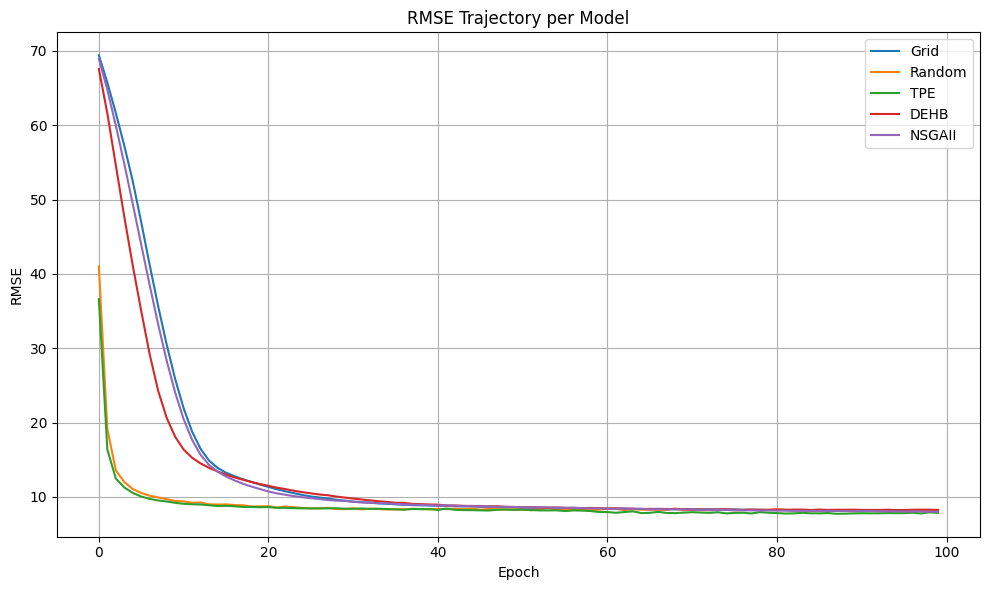

Model: Grid
Metrics:
  RMSE: 8.152656318876133
  MAE: 6.466367244720459
  R2: 0.8679302930831909
  runtime: 44.66760540008545
  epochs: 100
Best hp: {'lr': 0.001, 'momentum': 0.9, 'hidden_size': 8, 'weight_decay': 0.0001, 'batch_size': 32, 'dropout': 0.1}
----------------------------------------
Model: Random
Metrics:
  RMSE: 8.119578269191772
  MAE: 6.4504475593566895
  R2: 0.8689998388290405
  runtime: 27.8050799369812
  epochs: 100
Best hp: {'lr': 0.009593765041728812, 'momentum': 0.8468637027348839, 'hidden_size': 16, 'weight_decay': 0.00016194399134283115, 'batch_size': 64, 'dropout': 0.18972992571521785}
----------------------------------------
Model: TPE
Metrics:
  RMSE: 7.853219809151506
  MAE: 6.175175666809082
  R2: 0.877453625202179
  runtime: 28.44681167602539
  epochs: 100
Best hp: {'lr': 0.007861615941676454, 'momentum': 0.831506713103715, 'hidden_size': 32, 'weight_decay': 0.00011851096201963328, 'batch_size': 64, 'dropout': 0.10714970673736593}
-------------------------

In [ ]:
# Plot loss curves per model
plt.figure(figsize=(10, 6))

for name, result in results_summary.items():
    # Assuming result["Loss"] is a list or numpy array of losses per epoch
    plt.plot(result["RMSE_Traj"], label=name)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("RMSE Trajectory per Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print metrics and RMSE_Traj
for name, result in results_summary.items():
    print(f"Model: {name}")
    print("Metrics:")
    for metric, value in result["Metrics"].items():
        print(f"  {metric}: {value}")
    print(f"Best hp: {result['Params']}")
    print("-" * 40)

---

# Fuzzy Rules Test If they even work

---

In [ ]:
!pip -q install scikit-fuzzy

In [ ]:
# Robustly extract hour information from the dataset.
# Supports 'hour', 'Hour', 'timestamp', or 'datetime' columns.
# Used to split behavior into day vs night.


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def extract_hour(df):
    if "hour" in df.columns:
        return df["hour"].to_numpy()
    if "Hour" in df.columns:
        return df["Hour"].to_numpy()
    if "timestamp" in df.columns:
        return pd.to_datetime(df["timestamp"]).dt.hour.to_numpy()
    if "datetime" in df.columns:
        return pd.to_datetime(df["datetime"]).dt.hour.to_numpy()
    raise ValueError("No hour/Hour/timestamp/datetime column found")

def metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


In [ ]:
# Convert raw activity-related features into a normalized activity score [0,1].
# This represents how active the street environment is.
# Used as fuzzy input variable 'activity'.


target = "adjusted_light_intensity"

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

y_tr = df_train[target].astype(float).to_numpy()
y_te = df_test[target].astype(float).to_numpy()

X_tr = df_train.drop(columns=[target])
X_te = df_test.drop(columns=[target])

print("Train:", X_tr.shape, "Test:", X_te.shape)


Train: (9600, 16) Test: (2400, 16)


In [ ]:
# Compute normalized visibility score [0,1].
# Combines ambient light (lux) and day/night information.
# Used as fuzzy input variable 'visibility'.


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor

num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_tr.columns if c not in num_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

mlp_model = Pipeline([
    ("pre", pre),
    ("mlp", mlp),
])

mlp_model


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['zone_id',
                                                   'ambient_light_lux',
                                                   'motion_detected',
                                                   'temperature_celsius',
                                                   'occupancy_count',
                                                   'special_event_flag',
                                                   'energy_price_per_kwh',
                                                   'prev_hour_energy_usage_kwh',
                                                   'traffic_density',
                                                   'avg_pedestrian_s...
                                                   'lighting_action_class']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['timestamp', 'day_of_week',
                                                   'time_of_day',
                                                   'weather_condition'])])),
                ('mlp',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(128, 64),
                              max_iter=500, n_iter_no_change=15,
                              random_state=42, validation_fraction=0.15))])

In [ ]:
# Define fuzzy variables (activity, visibility, lighting).
# Define membership functions (low / medium / high).
# Define a complete rule base covering the whole input space.
# Output is normalized lighting intensity in [0,1].


mlp_model.fit(X_tr, y_tr)

yhat_mlp_te = mlp_model.predict(X_te)

rmse, mae, r2 = metrics(y_te, yhat_mlp_te)
print(f"MLP(test): RMSE ≈ {rmse:.2f}, MAE ≈ {mae:.2f}, R² ≈ {r2:.3f}")


MLP(test): RMSE ≈ 7.27, MAE ≈ 5.73, R² ≈ 0.895


In [ ]:
#Helper functions (hour extraction + metric formatting)
#Compute activity score from dataset (normalized to [0,1])

import numpy as np
import pandas as pd

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



def extract_hour(df: pd.DataFrame) -> np.ndarray:
    if "hour" in df.columns:
        return df["hour"].to_numpy()
    if "Hour" in df.columns:
        return df["Hour"].to_numpy()
    if "timestamp" in df.columns:
        return pd.to_datetime(df["timestamp"]).dt.hour.to_numpy()
    if "datetime" in df.columns:
        return pd.to_datetime(df["datetime"]).dt.hour.to_numpy()
    raise ValueError("No hour/Hour/timestamp/datetime column found")

def compute_activity_score(df: pd.DataFrame) -> np.ndarray:
    if "occupancy_count" in df.columns:
        occ = df["occupancy_count"].to_numpy(dtype=float)
    elif "occupancy" in df.columns:
        occ = df["occupancy"].to_numpy(dtype=float)
    else:
        raise ValueError("No occupancy_count/occupancy column found")

    p5, p95 = np.percentile(occ, 5), np.percentile(occ, 95)
    return np.clip((occ - p5) / (p95 - p5 + 1e-8), 0, 1)

def compute_visibility_score_weighted(df: pd.DataFrame, w_lux=0.4, w_day=0.6) -> np.ndarray:
    hour = extract_hour(df)
    is_day = ((hour >= 7) & (hour < 19)).astype(float)

    if "ambient_light_lux" in df.columns:
        lux = df["ambient_light_lux"].to_numpy(dtype=float)
    elif "ambient_light" in df.columns:
        lux = df["ambient_light"].to_numpy(dtype=float)
    else:
        lux = None

    if lux is None:
        lux_norm = is_day
    else:
        p5, p95 = np.percentile(lux, 5), np.percentile(lux, 95)
        lux_norm = np.clip((lux - p5) / (p95 - p5 + 1e-8), 0, 1)

    v = w_lux * lux_norm + w_day * is_day
    return np.clip(v, 0, 1)

def build_fuzzy_system():
    u = np.linspace(0, 1, 101)

    activity = ctrl.Antecedent(u, "activity")
    visibility = ctrl.Antecedent(u, "visibility")
    lighting = ctrl.Consequent(u, "lighting")

    activity["low"]  = fuzz.trimf(u, [0.0, 0.0, 0.5])
    activity["med"]  = fuzz.trimf(u, [0.2, 0.5, 0.8])
    activity["high"] = fuzz.trimf(u, [0.5, 1.0, 1.0])

    visibility["poor"]   = fuzz.trimf(u, [0.0, 0.0, 0.5])
    visibility["normal"] = fuzz.trimf(u, [0.2, 0.5, 0.8])
    visibility["good"]   = fuzz.trimf(u, [0.5, 1.0, 1.0])

    lighting["dim"]    = fuzz.trimf(u, [0.0, 0.0, 0.5])
    lighting["normal"] = fuzz.trimf(u, [0.2, 0.5, 0.8])
    lighting["full"]   = fuzz.trimf(u, [0.5, 1.0, 1.0])

    rules = [
        ctrl.Rule(activity["high"], lighting["full"]),
        ctrl.Rule(activity["med"] & visibility["poor"], lighting["full"]),
        ctrl.Rule(activity["med"] & visibility["normal"], lighting["normal"]),
        ctrl.Rule(activity["low"] & visibility["good"], lighting["dim"]),

        ctrl.Rule(activity["low"] & visibility["poor"], lighting["normal"]),
        ctrl.Rule(activity["low"] & visibility["normal"], lighting["dim"]),
        ctrl.Rule(activity["med"] & visibility["good"], lighting["normal"]),
        ctrl.Rule(activity["high"] & visibility["good"], lighting["full"]),
        ctrl.Rule(activity["high"] & visibility["poor"], lighting["full"]),
    ]

    return ctrl.ControlSystem(rules)

SYSTEM = build_fuzzy_system()

def fuzzy_predict_z(df_part: pd.DataFrame, w_lux=0.4, w_day=0.6) -> np.ndarray:
    a = compute_activity_score(df_part)
    v = compute_visibility_score_weighted(df_part, w_lux=w_lux, w_day=w_day)

    sim = ctrl.ControlSystemSimulation(SYSTEM)
    z = np.zeros(len(df_part), dtype=float)

    for i in range(len(df_part)):
        sim.input["activity"] = float(a[i])
        sim.input["visibility"] = float(v[i])
        sim.compute()
        z[i] = float(sim.output["lighting"])
    return z

def metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


In [ ]:
def fuzzy_predict_target_daynight(df_train, df_part, w_lux=0.4, w_day=0.6):
    z_tr = fuzzy_predict_z(df_train, w_lux=w_lux, w_day=w_day)
    z_te = fuzzy_predict_z(df_part,  w_lux=w_lux, w_day=w_day)

    y_tr = df_train[target].astype(float).to_numpy()

    h_tr = extract_hour(df_train)
    h_te = extract_hour(df_part)

    is_day_tr = (h_tr >= 7) & (h_tr < 19)
    is_day_te = (h_te >= 7) & (h_te < 19)

    # osobna kalibracja dla day i night: y ≈ alpha + beta*z
    Xd = np.vstack([np.ones_like(z_tr[is_day_tr]), z_tr[is_day_tr]]).T
    alpha_d, beta_d = np.linalg.lstsq(Xd, y_tr[is_day_tr], rcond=None)[0]

    Xn = np.vstack([np.ones_like(z_tr[~is_day_tr]), z_tr[~is_day_tr]]).T
    alpha_n, beta_n = np.linalg.lstsq(Xn, y_tr[~is_day_tr], rcond=None)[0]

    yhat = np.zeros(len(df_part), dtype=float)
    yhat[is_day_te]  = alpha_d + beta_d * z_te[is_day_te]
    yhat[~is_day_te] = alpha_n + beta_n * z_te[~is_day_te]

    return yhat, (float(alpha_d), float(beta_d), float(alpha_n), float(beta_n))

yhat_fuzzy_te, calib = fuzzy_predict_target_daynight(df_train, df_test)
rmse_f, mae_f, r2_f = metrics(y_te, yhat_fuzzy_te)

print(f"Fuzzy(test): RMSE ≈ {rmse_f:.2f}, MAE ≈ {mae_f:.2f}, R² ≈ {r2_f:.3f}")
print("Calib(day alpha,beta ; night alpha,beta):", calib)


Fuzzy(test): RMSE ≈ 19.49, MAE ≈ 15.85, R² ≈ 0.245
Calib(day alpha,beta ; night alpha,beta): (45.54203253815913, 31.28939478754636, 63.2173676812348, 21.811963167379982)


In [ ]:
yhat_mlp_tr = mlp_model.predict(X_tr)
yhat_fuzzy_tr, _ = fuzzy_predict_target_daynight(df_train, df_train)

dev_tr = np.abs(yhat_mlp_tr - yhat_fuzzy_tr)
dev_te = np.abs(yhat_mlp_te - yhat_fuzzy_te)

thr = np.percentile(dev_tr, 90)
is_out_te = dev_te > thr

print(f"Deviation threshold (p90 train): {thr:.2f}")
print(f"Outliers in test: {is_out_te.mean()*100:.2f}%")


Deviation threshold (p90 train): 31.31
Outliers in test: 7.58%


In [ ]:
def correct_mlp_with_fuzzy(y_mlp, y_fuzzy, dev, thr, w_max=0.7):
    # dev<=thr -> w≈0, dev much bigger -> w do w_max
    w = np.clip((dev - thr) / (thr + 1e-8), 0, 1) * w_max
    return (1 - w) * y_mlp + w * y_fuzzy, w

yhat_corr_te, w_te = correct_mlp_with_fuzzy(yhat_mlp_te, yhat_fuzzy_te, dev_te, thr, w_max=0.7)


In [ ]:
# Evaluate fuzzy model performance on test set.
# Metrics remember:
# - RMSE / MAE are in original units
# - R² measures how much variance is explained
# Also compute percentage-based errors (nRMSE, nMAE, MAPE).


rmse0, mae0, r20 = metrics(y_te, yhat_mlp_te)
rmse1, mae1, r21 = metrics(y_te, yhat_corr_te)

print(f"MLP(test):        RMSE ≈ {rmse0:.2f}, MAE ≈ {mae0:.2f}, R² ≈ {r20:.3f}")
print(f"MLP+Fuzzy(test):  RMSE ≈ {rmse1:.2f}, MAE ≈ {mae1:.2f}, R² ≈ {r21:.3f}")

# how it looks on outliners
if is_out_te.any():
    rmse_o0, mae_o0, r2_o0 = metrics(y_te[is_out_te], yhat_mlp_te[is_out_te])
    rmse_o1, mae_o1, r2_o1 = metrics(y_te[is_out_te], yhat_corr_te[is_out_te])
    print()
    print(f"Outliers only ({is_out_te.mean()*100:.2f}%):")
    print(f"  MLP:       RMSE ≈ {rmse_o0:.2f}, MAE ≈ {mae_o0:.2f}, R² ≈ {r2_o0:.3f}")
    print(f"  MLP+Fuzzy: RMSE ≈ {rmse_o1:.2f}, MAE ≈ {mae_o1:.2f}, R² ≈ {r2_o1:.3f}")


MLP(test):        RMSE ≈ 7.27, MAE ≈ 5.73, R² ≈ 0.895
MLP+Fuzzy(test):  RMSE ≈ 7.75, MAE ≈ 5.93, R² ≈ 0.881

Outliers only (7.58%):
  MLP:       RMSE ≈ 7.30, MAE ≈ 5.87, R² ≈ 0.938
  MLP+Fuzzy: RMSE ≈ 12.18, MAE ≈ 8.52, R² ≈ 0.826


In [ ]:
# Compare fuzzy model against:
# 1) Global mean baseline
# 2) Hour-based mean baseline
# Shows that fuzzy logic improves over naive baselines,
# but is still limited by input information.


print("Final comparison:")
print(f"MLP:       RMSE≈{rmse0:.2f}, MAE≈{mae0:.2f}, R²≈{r20:.3f}")
print(f"MLP+Fuzzy: RMSE≈{rmse1:.2f}, MAE≈{mae1:.2f}, R²≈{r21:.3f}")
print(f"Flagged as outliers: {is_out_te.mean()*100:.2f}% (threshold p90 train deviation)")


Final comparison:
MLP:       RMSE≈7.27, MAE≈5.73, R²≈0.895
MLP+Fuzzy: RMSE≈7.75, MAE≈5.93, R²≈0.881
Flagged as outliers: 7.58% (threshold p90 train deviation)
